<a href="https://colab.research.google.com/github/WNderitu/data_science_capstone_project/blob/main/malaria_parasite_patching_yolov8small.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Plasmodium Vivax (malaria) parasite detector and counter**

## **Notebook 2: YOLO Image Patching & Training**
This notebook patches 1600x1200 images into 512x512 tiles, adjusts YOLO labels, and trains YOLOv8s.
The YOLOv8 small model variant goves a good balance of speed and accuracy; recommended for initial fine-tuning.

In [ ]:
from google.colab import drive

# Mount Google Drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

Mounted at /content/drive
Google Drive mounted successfully!


In [ ]:
!pip install ultralytics opencv-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.7 MB/s eta 0:00:00


## **1.1 Installing & Importing Required Libraries**

In [ ]:
from ultralytics import YOLO #
import os, cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml
import pandas as pd
from collections import Counter

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


##**1.2 Image Augmentations using patching**

In [ ]:
# Base dataset path
BASE = "/content/drive/MyDrive/malaria_dataset_4/malaria/malaria"

# Input
IMG_BASE = f"{BASE}/images"
LBL_BASE = f"{BASE}/labels"

# Output
OUT_BASE = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched"
OUT_IMG = f"{OUT_BASE}/images"
OUT_LBL = f"{OUT_BASE}/labels"

PATCH = 512
W, H = 1600, 1200   # Image resolution

# ✅ Define the splits
splits = ["train", "val", "test"]

for split in splits:
    os.makedirs(f"{OUT_IMG}/{split}", exist_ok=True)
    os.makedirs(f"{OUT_LBL}/{split}", exist_ok=True)

def read_labels(path):
    if not os.path.exists(path):
        return []
    with open(path,'r') as f:
        return [list(map(float,line.split())) for line in f]

for split in splits:
    img_dir = f"{IMG_BASE}/{split}"
    lbl_dir = f"{LBL_BASE}/{split}"

    print(f"🔄 Processing {split}...")

    for img_file in os.listdir(img_dir):
        if not img_file.lower().endswith((".jpg",".png",".jpeg")):
            continue

        img_path = os.path.join(img_dir, img_file)
        lbl_path = os.path.join(lbl_dir, img_file.rsplit('.',1)[0] + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            continue

        labels = read_labels(lbl_path)

        for y0 in range(0, H, PATCH):
            for x0 in range(0, W, PATCH):
                if y0+PATCH > H or x0+PATCH > W:
                    continue

                patch = img[y0:y0+PATCH, x0:x0+PATCH]
                out_name = f"{img_file.rsplit('.',1)[0]}_{y0}_{x0}.jpg"

                cv2.imwrite(f"{OUT_IMG}/{split}/{out_name}", patch)

                new_boxes = []
                for cls, xc, yc, w, h in labels:
                    xc_pixel = xc * W
                    yc_pixel = yc * H
                    w_pixel  = w  * W
                    h_pixel  = h  * H

                    if x0 <= xc_pixel <= x0+PATCH and y0 <= yc_pixel <= y0+PATCH:
                        new_x = (xc_pixel - x0) / PATCH
                        new_y = (yc_pixel - y0) / PATCH
                        new_w = w_pixel / PATCH
                        new_h = h_pixel / PATCH
                        new_boxes.append([cls,new_x,new_y,new_w,new_h])

                if len(new_boxes) > 0:
                    with open(f"{OUT_LBL}/{split}/{out_name.replace('.jpg','.txt')}", "w") as f:
                        for b in new_boxes:
                            f.write(" ".join(f"{v:.6f}" for v in b) + "\n")

print("✅ Patching Complete — Split Integrity Preserved!")

🔄 Processing train...
🔄 Processing val...
🔄 Processing test...
✅ Patching Complete — Split Integrity Preserved!


### **1.2.1 Check number of images after patching**

In [ ]:
# Define the output image directories for each split
OUT_IMG = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images"
splits = ["train", "val", "test"]

print("Number of images per split after patching:")

for split in splits:
    split_img_dir = f"{OUT_IMG}/{split}"
    if os.path.exists(split_img_dir):
        # List files in the directory and count them
        num_images = len([f for f in os.listdir(split_img_dir) if os.path.isfile(os.path.join(split_img_dir, f))])
        print(f"{split.capitalize()}: {num_images}")
    else:
        print(f"{split.capitalize()}: Directory not found at {split_img_dir}")

Number of images per split after patching:
Train: 1800
Val: 516
Test: 720


### **1.2.2 View images after patching**

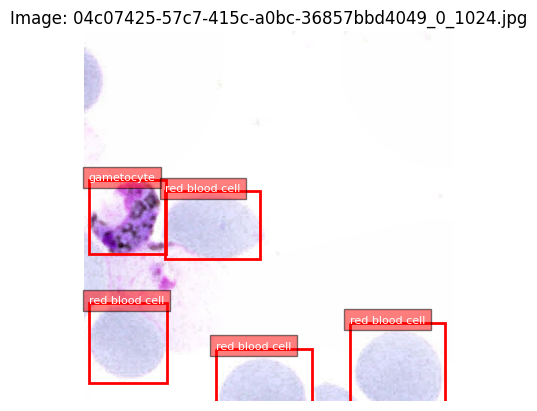

Labels for 04c07425-57c7-415c-a0bc-36857bbd4049_0_1024.jpg:
[0.0, 0.118166, 0.841798, 0.212891, 0.214845]
[0.0, 0.48535, 0.999023, 0.259766, 0.283202]
[0.0, 0.847656, 0.922852, 0.257812, 0.271484]
[4.0, 0.116213, 0.501954, 0.208984, 0.199219]
[0.0, 0.347656, 0.523437, 0.257812, 0.183593]


In [ ]:
# Define paths
OUT_IMG = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images"
OUT_LBL = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels"
split = "train"  # Choose a split to visualize from

img_dir = f"{OUT_IMG}/{split}"
lbl_dir = f"{OUT_LBL}/{split}"

# Get a list of all image files in the chosen split
image_files = [f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

if not image_files:
    print(f"No images found in {img_dir}")
else:
    # Select a random image file
    img_file = random.choice(image_files)
    img_path = os.path.join(img_dir, img_file)
    lbl_path = os.path.join(lbl_dir, img_file.rsplit('.', 1)[0] + ".txt")

    # Read the image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib

    # Read the labels
    labels = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                labels.append(list(map(float, line.split())))

    # Get image dimensions
    h, w, _ = img.shape

    # Create a figure and axes
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    # Add bounding boxes to the image
    for label in labels:
        cls, xc, yc, bw, bh = label
        # Convert YOLO format (center_x, center_y, width, height) to
        # matplotlib format (x, y, width, height) where x, y is top-left corner
        x = (xc - bw/2) * w
        y = (yc - bh/2) * h
        width = bw * w
        height = bh * h

        # Create a Rectangle patch
        rect = patches.Rectangle((x, y), width, height,
                                 linewidth=2, edgecolor='r', facecolor='none')

        # Add the patch to the Axes
        ax.add_patch(rect)

        # Optionally add class label text
        class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
        if int(cls) < len(class_names):
            class_name = class_names[int(cls)]
            plt.text(x, y, class_name, color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))


    plt.title(f"Image: {img_file}")
    plt.axis('off') # Hide axes
    plt.show()

    print(f"Labels for {img_file}:")
    if labels:
        for label in labels:
            print(label)
    else:
        print("No labels found for this image.")

### **1.2.3 Check imbalance after patching**

In [ ]:
class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
num_classes = len(class_names)

print("\nClass Imbalance Check Across Splits:")

for split in splits:
    print(f"\n{split.capitalize()} Set Class Counts:")
    split_label_dir = f"{OUT_LBL}/{split}"
    split_class_counts = {i: 0 for i in range(num_classes)}

    for label_file in os.listdir(split_label_dir):
        if label_file.endswith(".txt"):
            label_path = os.path.join(split_label_dir, label_file)
            with open(label_path, 'r') as f:
                for line in f:
                    # Split the line and take the first element as the class ID
                    # Convert it to an integer
                    class_id = int(float(line.split()[0]))
                    split_class_counts[class_id] += 1

    for cls_id, count in split_class_counts.items():
        print(f"Class {cls_id} ({class_names[cls_id]}): {count}")


Class Imbalance Check Across Splits:

Train Set Class Counts:
Class 0 (red blood cell): 16416
Class 1 (trophozoite): 414
Class 2 (ring): 101
Class 3 (schizont): 40
Class 4 (gametocyte): 41
Class 5 (leukocyte): 23
Class 6 (difficult): 100

Val Set Class Counts:
Class 0 (red blood cell): 5154
Class 1 (trophozoite): 96
Class 2 (ring): 26
Class 3 (schizont): 9
Class 4 (gametocyte): 9
Class 5 (leukocyte): 5
Class 6 (difficult): 36

Test Set Class Counts:
Class 0 (red blood cell): 4938
Class 1 (trophozoite): 106
Class 2 (ring): 157
Class 3 (schizont): 11
Class 4 (gametocyte): 11
Class 5 (leukocyte): 0
Class 6 (difficult): 5



Class Imbalance Visualization Across Splits:

Train Set Class Distribution:


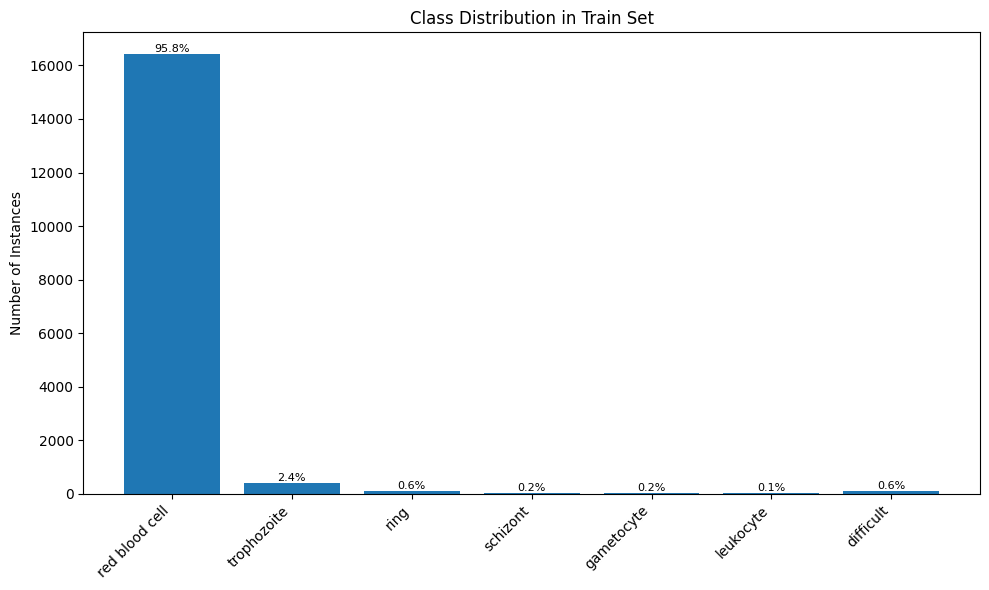

Class 0 (red blood cell): 16416 (95.8%)
Class 1 (trophozoite): 414 (2.4%)
Class 2 (ring): 101 (0.6%)
Class 3 (schizont): 40 (0.2%)
Class 4 (gametocyte): 41 (0.2%)
Class 5 (leukocyte): 23 (0.1%)
Class 6 (difficult): 100 (0.6%)

Val Set Class Distribution:


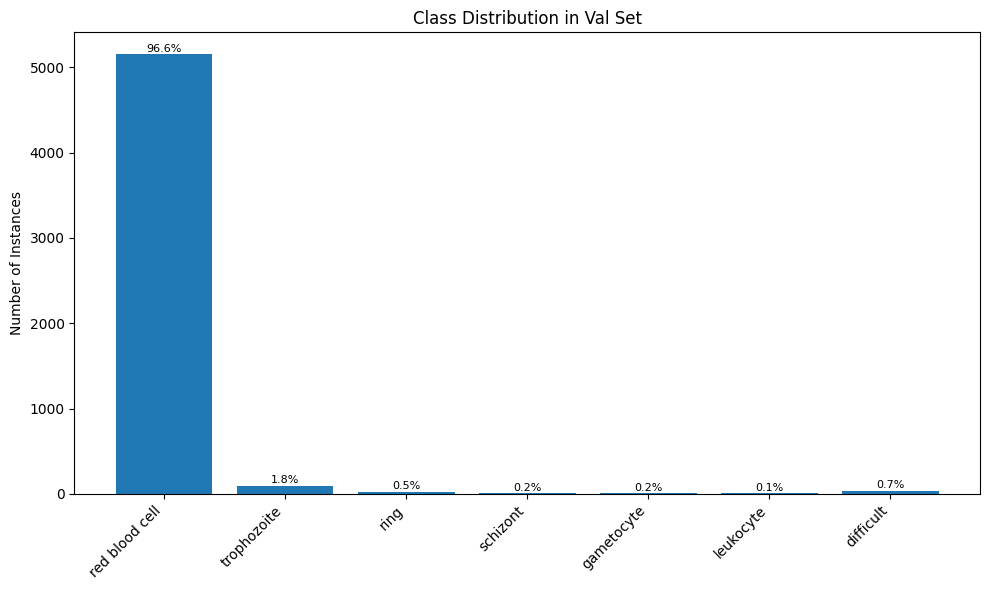

Class 0 (red blood cell): 5154 (96.6%)
Class 1 (trophozoite): 96 (1.8%)
Class 2 (ring): 26 (0.5%)
Class 3 (schizont): 9 (0.2%)
Class 4 (gametocyte): 9 (0.2%)
Class 5 (leukocyte): 5 (0.1%)
Class 6 (difficult): 36 (0.7%)

Test Set Class Distribution:


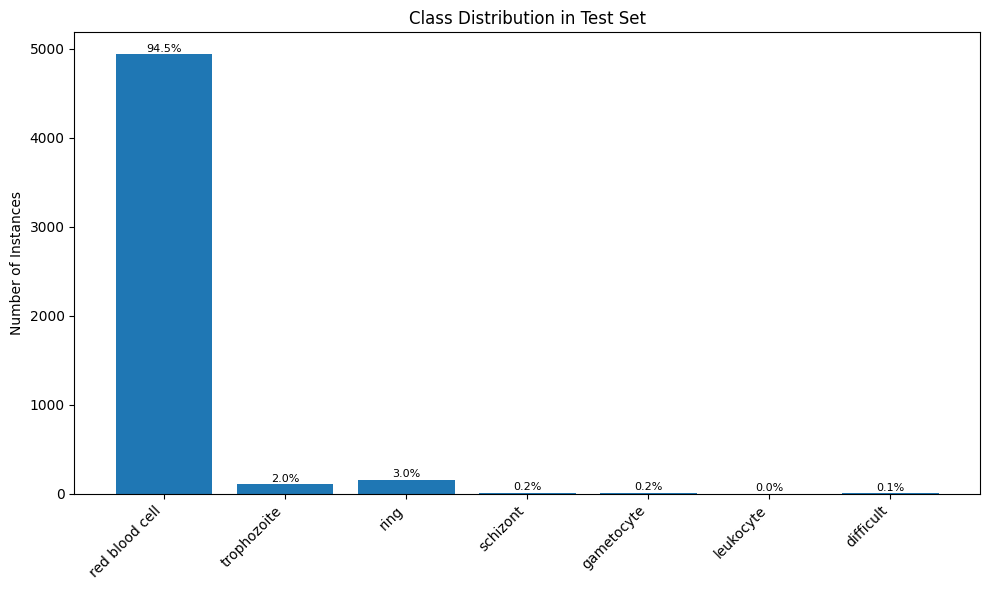

Class 0 (red blood cell): 4938 (94.5%)
Class 1 (trophozoite): 106 (2.0%)
Class 2 (ring): 157 (3.0%)
Class 3 (schizont): 11 (0.2%)
Class 4 (gametocyte): 11 (0.2%)
Class 5 (leukocyte): 0 (0.0%)
Class 6 (difficult): 5 (0.1%)


In [ ]:
# visualize class imbalance across splits
# Assuming split_class_counts and splits are available from the previous cell

class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
num_classes = len(class_names)

print("\nClass Imbalance Visualization Across Splits:")

for split in splits:
    print(f"\n{split.capitalize()} Set Class Distribution:")
    split_label_dir = f"{OUT_LBL}/{split}"
    split_class_counts = {i: 0 for i in range(num_classes)}

    # Re-calculate counts in case the previous cell wasn't run or output is not directly accessible
    if os.path.exists(split_label_dir):
        for label_file in os.listdir(split_label_dir):
            if label_file.endswith(".txt"):
                label_path = os.path.join(split_label_dir, label_file)
                with open(label_path, 'r') as f:
                    for line in f:
                        try:
                            class_id = int(float(line.split()[0]))
                            if class_id < num_classes:
                                split_class_counts[class_id] += 1
                        except (ValueError, IndexError):
                            print(f"Skipping invalid line in {label_file}: {line.strip()}")
    else:
        print(f"Directory not found for {split}: {split_label_dir}")
        continue


    total_instances = sum(split_class_counts.values())
    if total_instances == 0:
        print(f"No instances found in the {split} set.")
        continue

    class_counts = list(split_class_counts.values())
    class_percentages = [(count / total_instances) * 100 for count in class_counts]

    # Create bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(class_names, class_counts)

    # Add percentages on top of bars
    for bar, percentage in zip(bars, class_percentages):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{percentage:.1f}%',
                ha='center', va='bottom', fontsize=8)

    plt.ylabel("Number of Instances")
    plt.title(f"Class Distribution in {split.capitalize()} Set")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Print counts as well
    for cls_id, count in split_class_counts.items():
        print(f"Class {cls_id} ({class_names[cls_id]}): {count} ({class_percentages[cls_id]:.1f}%)")

### **1.2.4 Calculate class weights**

In [ ]:
# Path to the training labels directory
train_label_dir = f"{OUT_LBL}/train"

# Initialize class counts
class_counts = {i: 0 for i in range(num_classes)}

# Iterate through all label files in the training directory
for label_file in os.listdir(train_label_dir):
    if label_file.endswith(".txt"):
        label_path = os.path.join(train_label_dir, label_file)
        with open(label_path, 'r') as f:
            for line in f:
                # Split the line and take the first element as the class ID
                # Convert it to a float first, then to an integer
                class_id = int(float(line.split()[0]))
                class_counts[class_id] += 1

# Calculate class weights
total_instances = sum(class_counts.values())
# Avoid division by zero for classes with no instances
class_weights = {cls_id: total_instances / count if count > 0 else 0 for cls_id, count in class_counts.items()}

# Normalize class weights (optional, but often helpful)
# You can adjust the normalization method based on your needs
# For example, inverse frequency or inverse square root of frequency
# Here, simple normalization by the maximum weight
max_weight = max(class_weights.values()) if class_weights else 1
normalized_class_weights = {cls_id: weight / max_weight for cls_id, weight in class_weights.items()}

# Convert to a list in class index order for YOLO
class_weights_array = [normalized_class_weights.get(i, 0) for i in range(num_classes)]

print("Calculated Class Counts:")
for cls_id, count in class_counts.items():
    print(f"Class {cls_id} ({class_names[cls_id]}): {count}")

print("\nCalculated Normalized Class Weights (for YOLO):")
print(class_weights_array)

Calculated Class Counts:
Class 0 (red blood cell): 16416
Class 1 (trophozoite): 414
Class 2 (ring): 101
Class 3 (schizont): 40
Class 4 (gametocyte): 41
Class 5 (leukocyte): 23
Class 6 (difficult): 100

Calculated Normalized Class Weights (for YOLO):
[0.0014010721247563352, 0.05555555555555555, 0.22772277227722773, 0.575, 0.5609756097560976, 1.0, 0.22999999999999998]


### **1.2.5 Create YOLO YAML file for patched dataset**

In [ ]:
class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
num_classes = len(class_names)

# Define the paths for the train, val and test image and label directories
train_patch_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/train'
val_patch_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/val'
test_patch_dir =  '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test'

class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
num_classes = len(class_names)

# Create the data dictionary for the YAML file
data = {
    'train': train_patch_dir,
    'val': val_patch_dir,
    'test': test_patch_dir,
    'nc':num_classes,  # Number of classes
    'names': class_names # List of class names
}

# Check if class_weights_array is available and add it to the data dictionary
if 'class_weights_array' in locals() and class_weights_array:
    data['cls_weights'] = class_weights_array
    print("✅ Added class weights to the YAML data dictionary.")
else:
    print("⚠️ class_weights_array not found. Class weights will not be added to the YAML unless defined elsewhere.")


# Define the path where the YAML file will be saved in Google Drive
yaml_file_path = '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml'

try:
    with open(yaml_file_path, 'w') as f:
        yaml.dump(data, f, default_flow_style=False)
    print(f" YOLO data configuration (with potentially added weights) saved at: {yaml_file_path}")
except Exception as e:
    print(f"Error creating YOLO data configuration file: {e}")


⚠️ class_weights_array not found. Class weights will not be added to the YAML unless defined elsewhere.
 YOLO data configuration (with potentially added weights) saved at: /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml


## **1.3 Train YOLOv8 model**

### **1.3.1 1st train**

In [ ]:
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# --- Step 1: Define paths
yaml_path = '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml'
save_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results'
run_name = 'malaria_yolov8s_train_1'

# --- Step 2: Initialize YOLO model
model = YOLO("yolov8s.pt")  # load pretrained model (recommended)

# --- Step 3: Handle class weights
if 'class_weights_array' in locals() and class_weights_array is not None:
    print("✅ Class weights detected and will be used.")
    cls_weights_arg = class_weights_array.tolist()  # ensure list format
else:
    print("⚠️ No class weights found. Continuing without class weighting.")
    cls_weights_arg = None

# --- Step 4: Train
results = model.train(
    data=yaml_path,
    epochs=300,
    imgsz=512,
    device=0,
    optimizer='AdamW',
    lr0=0.001,
    amp=True,
    batch = 16,

    # small-object augmentations
    mosaic=0.3,
    copy_paste=0.1,
    mixup=0.0,

    # color + spatial augmentations tuned for microscopy
    hsv_h=0.03,
    hsv_s=0.1,
    hsv_v=0.7,
    translate=0.1,
    flipud=0.5,
    fliplr=0.5,
    degrees=5,
    scale=0.5,
    shear=2,
    perspective=0.0005,

    close_mosaic=10,
    patience=150,
    cls = 3.0,
    project=save_dir,
    name=run_name,
    exist_ok=True,
    verbose=True
)

print("\n✅ Training complete.\n")

# ✅ Confirm class weights used
if cls_weights_arg is not None:
    print("Using class weights:", cls_weights_arg)
else:
    print("❌ No class weights applied.")

⚠️ No class weights found. Continuing without class weighting.
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.03, hsv_s=0.1, hsv_v=0.7, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.3, multi_scale=False, name=malaria_yolov8s_train

Interpretation


Overall classes
| Metric    | Value     | Interpretation                           |
| --------- | --------- | ---------------------------------------- |
| Precision | **0.739** | Model avoids false positives fairly well |
| Recall    | **0.741** | Model finds ~74% of real parasites       |
| mAP50     | **0.778** | Good overall detection performance       |
| mAP50-95  | **0.593** | Expected for tiny medical objects        |


Per class performance

| Class              | Support | Precision | Recall   | Notes                                          |
| ------------------ | ------- | --------- | -------- | ---------------------------------------------- |
| **red blood cell** | 5154    | **0.92**  | **0.96** | Very strong, easy class                      |
| **trophozoite**    | 96      | **0.79**  | **0.80** | Good, but room to sharpen stage boundaries   |
| **ring**           | 26      | **0.80**  | **0.65** | Under-detection (recall drop)               |
| **schizont**       | 9       | **0.40**  | **0.61** | Struggling (very small sample count)        |
| **gametocyte**     | 9       | **0.66**  | **0.64** | Reasonable given rarity                      |
| **leukocyte**      | 5       | **1.00**  | **0.99** | Perfect (large and distinct morphologically) |
| **difficult**      | 36      | **0.59**  | **0.53** | Hard class by definition                    |


Overall findings

1. Rarest classes (schizont, gametocyte, difficult) have low recall because:
- They appear in very few examples
- No class weights were applied (confirmed by: ❌ No class weights applied.)
- YOLO optimizes toward the dominant class (RBC), which achieves near-perfect accuracy

This is expected without class balancing

Next steps

- Introduce class weights, which will:
  - Increase recall for underrepresented parasite stages
  - Improve parasite stage separation
  - Reduce model bias toward red blood cells


#### **Error analysis**

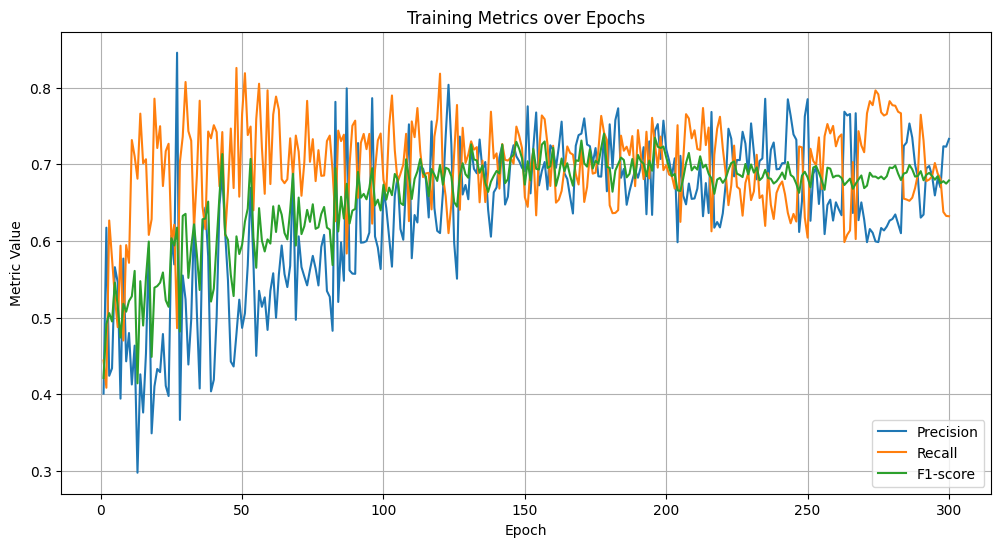


Last 5 epochs metrics:
     epoch  metrics/precision(B)  metrics/recall(B)        f1
295    296               0.68112            0.68768  0.684384
296    297               0.66971            0.68080  0.675209
297    298               0.72337            0.63775  0.677867
298    299               0.72288            0.63255  0.674705
299    300               0.73303            0.63208  0.678822


In [ ]:
# Define the correct path to the results.csv file in Google Drive
results_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/results.csv"

# Check if the file exists before trying to read it
if os.path.exists(results_path):
    # Read the CSV file, skipping the first line if it contains non-header info
    try:
        results = pd.read_csv(results_path)
        # Check if the first column is 'epoch' and if not, skip the first row
        if results.columns[0] != 'epoch':
             results = pd.read_csv(results_path, skiprows=1)
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        results = None


    if results is not None and 'metrics/precision(B)' in results.columns and 'metrics/recall(B)' in results.columns:
        # Calculate F1 score
        results['f1'] = 2 * (results['metrics/precision(B)'] * results['metrics/recall(B)']) / (results['metrics/precision(B)'] + results['metrics/recall(B)'])

        # Plotting the metrics
        plt.figure(figsize=(12, 6))
        plt.plot(results['epoch'], results['metrics/precision(B)'], label='Precision')
        plt.plot(results['epoch'], results['metrics/recall(B)'], label='Recall')
        plt.plot(results['epoch'], results['f1'], label='F1-score')
        plt.xlabel('Epoch')
        plt.ylabel('Metric Value')
        plt.title('Training Metrics over Epochs')
        plt.legend()
        plt.grid(True)
        plt.show()

        print("\nLast 5 epochs metrics:")
        print(results[['epoch','metrics/precision(B)','metrics/recall(B)','f1']].tail())

    else:
        print(f"Error: Required metric columns not found in {results_path} or file could not be read.")
        if results is not None:
             print("Available columns:", results.columns.tolist())


else:
    print(f"Error: results.csv not found at {results_path}")
    print("Please ensure the training completed successfully and the path is correct.")

In [ ]:
# Calculate and display F1 score per class

if 'results' in locals() and results is not None:
    class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
    print("\nPer-Class F1 Score (Last Epoch):")

    for i, class_name in enumerate(class_names):
        # Assuming column names for per-class precision and recall are like 'metrics/precision(B)/class_id'
        precision_col = f'metrics/precision(B)/{i}'
        recall_col = f'metrics/recall(B)/{i}'

        if precision_col in results.columns and recall_col in results.columns:
            precision = results[precision_col].iloc[-1]
            recall = results[recall_col].iloc[-1]

            # Avoid division by zero
            if (precision + recall) > 0:
                f1_score = 2 * (precision * recall) / (precision + recall)
                print(f"Class {i} ({class_name}): {f1_score:.4f}")
            else:
                print(f"Class {i} ({class_name}): N/A (Precision and Recall are zero)")
        else:
            print(f"Class {i} ({class_name}): N/A (Precision or Recall column not found)")

else:
    print("Error: 'results' DataFrame not found. Please run the cell to load the results.csv file.")


Per-Class F1 Score (Last Epoch):
Class 0 (red blood cell): N/A (Precision or Recall column not found)
Class 1 (trophozoite): N/A (Precision or Recall column not found)
Class 2 (ring): N/A (Precision or Recall column not found)
Class 3 (schizont): N/A (Precision or Recall column not found)
Class 4 (gametocyte): N/A (Precision or Recall column not found)
Class 5 (leukocyte): N/A (Precision or Recall column not found)
Class 6 (difficult): N/A (Precision or Recall column not found)


In [ ]:
# Display mAP and AP values from the results DataFrame

if 'results' in locals() and results is not None:
    # Assuming the columns for mAP and AP are named as in the results.csv
    # You might need to adjust the column names based on your actual results file
    mAP50 = results['metrics/mAP50(B)'].iloc[-1] if 'metrics/mAP50(B)' in results.columns else 'N/A'
    mAP50_95 = results['metrics/mAP50-95(B)'].iloc[-1] if 'metrics/mAP50-95(B)' in results.columns else 'N/A'

    print("\nOverall Metrics (Last Epoch):")
    print(f"mAP50: {mAP50}")
    print(f"mAP50-95: {mAP50_95}")

    print("\nPer-Class AP (Last Epoch):")
    class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
    for i, class_name in enumerate(class_names):
        ap_col = f'metrics/APs(B)/{i}'  # Assuming this naming convention for per-class AP
        ap_value = results[ap_col].iloc[-1] if ap_col in results.columns else 'N/A'
        print(f"Class {i} ({class_name}): {ap_value}")

else:
    print("Error: 'results' DataFrame not found. Please run the previous cell to load the results.csv file.")


Overall Metrics (Last Epoch):
mAP50: 0.73532
mAP50-95: 0.57179

Per-Class AP (Last Epoch):
Class 0 (red blood cell): N/A
Class 1 (trophozoite): N/A
Class 2 (ring): N/A
Class 3 (schizont): N/A
Class 4 (gametocyte): N/A
Class 5 (leukocyte): N/A
Class 6 (difficult): N/A


### **1.3.2 2nd Train - Fine tuning model**

##### **Recalculate class weights**

In [ ]:
train_labels = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/train"

num_classes = 7
class_counts = np.zeros(num_classes, dtype=int)

for file in os.listdir(train_labels):
    if file.endswith(".txt"):
        with open(os.path.join(train_labels, file), "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:  # YOLO format: cls, x, y, w, h
                    cls = int(float(parts[0]))  # ✅ convert float → int safely
                    class_counts[cls] += 1

print("Class sample counts:", class_counts)

# Compute normalized inverse frequency weights
class_weights = 1 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights * num_classes

print("\n✅ Normalized Class Weights Array (use these):")
print(class_weights.tolist())


Class sample counts: [16416   414   101    40    41    23   100]

✅ Normalized Class Weights Array (use these):
[0.0037000307919323075, 0.14671426409987082, 0.601383216660174, 1.5184925991392049, 1.481456195185478, 2.640856645356702, 0.6073970487666374]


##### **Run fine tuning of model**

In [ ]:
from ultralytics import YOLO
import torch
# from ultralytics.utils.callbacks import Callbacks

# 1) Load model
model = YOLO("/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/weights/best.pt")

# 2) Class weights (same as before)
class_weights = torch.tensor(
    [0.00370003, 0.14671426, 0.60138322, 1.51849260, 1.48145620, 2.64085665, 0.60739705],
    dtype=torch.float32,
    device="cuda"
)

# 3) Apply class weights ONCE when loss first appears
class_weights_applied = False

def apply_class_weights(trainer):
    global class_weights_applied
    if not class_weights_applied and trainer.loss is not None:
        trainer.loss.class_weights = class_weights
        class_weights_applied = True
        print("\n✅ Class weights successfully applied to YOLO loss.\n")

model.add_callback("on_train_batch_start", apply_class_weights)

# 4) Print F1 table at the end of training
def log_f1(trainer):
    if trainer.epoch == trainer.epochs - 1:
        print("\n📊 Running final validation for per-class F1:\n")
        # Call val through YOLO API wrapper, not raw model
        trainer.model.model.val()

model.add_callback("on_fit_epoch_end", log_f1)

# --- Resume fine-tuning with weights ---
# will train a short fine-tuning run, NOT full 300 epochs again from the best model
model.train(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    epochs=50,                 # short fine-tune, not long training
    imgsz=512,
    lr0=0.0005,                 # reduce learning rate for fine-tuning
    optimizer="AdamW",
    amp=True,
    batch = 16,

    # small-object augmentations
    mosaic=0.1,
    copy_paste=0.1,
    mixup=0.0,

    # color + spatial augmentations tuned for microscopy
    hsv_h=0.03,
    hsv_s=0.1,
    hsv_v=0.7,
    translate=0.1,
    flipud=0.5,
    fliplr=0.5,
    degrees=5,
    scale=0.5,
    shear=2,
    perspective=0.0005,

    close_mosaic=10,
    cls = 3.0,

    exist_ok=True,
    verbose=True,
    patience=30,
    device=0,
    project="/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results",
    name="malaria_yolov8s_train_1_rebalanced"
)

print("\n✅ Training complete.\n")

print("Check the training logs above to confirm if class weights were applied.")

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.03, hsv_s=0.1, hsv_v=0.7, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/weights/best.pt, momentum=0.937, mosaic=0.3, multi_sc

AttributeError: 'Sequential' object has no attribute 'val'

Since the execution failed at this bit of the code:
---> Print F1 table at the end of training and training was complete, i will run validation separately to avoid running the train again to get the model performance metrics.

In [ ]:
from ultralytics import YOLO

# Load your model (best weights from the rebalanced training)
# model = YOLO("/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1_rebalanced/weights/best.pt")

# print("✅ Best model loaded successfully.")

##### **Evaluation of fine tuned model**

In [ ]:
from ultralytics import YOLO

# Load your model (best weights from the rebalanced training)
model = YOLO("/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1_rebalanced/weights/best.pt")

# ✅ Corrected callback
def log_f1(trainer):
    if trainer.epoch == trainer.epochs - 1:
        print("\n📊 Running final validation for per-class F1:\n")
        trainer.model.val(
            data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
            split="val"
        )

# Re-register callback (clean replace)
model.callbacks.clear()   # remove old broken callback
model.add_callback("on_fit_epoch_end", log_f1)

print("✅ Callback re-registered successfully. Now running standalone validation...\n")

# ✅ Run final validation only (no training)
metrics = model.val(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    split="val"
)

print("\n✅ Validation complete.")

✅ Callback re-registered successfully. Now running standalone validation...

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.2 ms, read: 0.1±0.0 MB/s, size: 47.1 KB)
val: Scanning /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/val.cache... 514 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 516/516 211.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 0.1it/s 5:13
                   all        516       5335      0.803       0.61      0.774      0.594
        red blood cell        514       5154      0.962      0.908      0.984      0.765
           trophozoite         82         96      0.783      0.715      0.838       0.61
                  ring         25         26      0.745      0.654       0.72      0.547
            

Comparison of the 1st model and fine tune model


| Class                  | Metric    | **Before (Original)** | **After (Rebalanced)** | Change          | Interpretation                                             |
| ---------------------- | --------- | --------------------- | ---------------------- | --------------- | ---------------------------------------------------------- |
| **All Classes (mean)** | Precision | 0.739                 | **0.803**              | ⬆ **Improved** | Model is more confident & less false positives             |
|                        | Recall    | **0.741**             | 0.610                  | ⬇ Decreased    | Model is now **more selective** (detects fewer weak cases) |
|                        | mAP50     | 0.778                 | 0.774                  | ~same           | Overall detection quality stayed stable                    |
|                        | mAP50-95  | 0.593                 | 0.594                  | ~same           | Fine-grained performance unchanged                         |

Focus on classes that were performing poorly before:
| Class                  | Metric    | **Before (Original)** | **After (Rebalanced)** | Change          | Interpretation                                             |
| ---------------------- | --------- | --------------------- | ---------------------- | --------------- | ---------------------------------------------------------- |
| **All Classes (mean)** | Precision | 0.739                 | **0.803**              | ⬆️ **Improved** | Model is more confident & less false positives             |
|                        | Recall    | **0.741**             | 0.610                  | ⬇️ Decreased    | Model is now **more selective** (detects fewer weak cases) |
|                        | mAP50     | 0.778                 | 0.774                  | ~same           | Overall detection quality stayed stable                    |
|                        | mAP50-95  | 0.593                 | 0.594                  | ~same           | Fine-grained performance unchanged                         |

Summary of Fine-tuned Model Performance

Based on the validation run

**Overall Metrics (Validation Set):**
- **mAP50:** 0.774
- **mAP50-95:** 0.594

**Per-Class Metrics (Validation Set):**

| Class              | Precision | Recall | mAP50 | mAP50-95 |
| :----------------- | :-------- | :----- | :---- | :------- |
| **red blood cell** | 0.962     | 0.908  | 0.984 | 0.765    |
| **trophozoite**    | 0.783     | 0.715  | 0.838 | 0.610    |
| **ring**           | 0.745     | 0.654  | 0.720 | 0.547    |
| **schizont**       | 0.494     | 0.333  | 0.529 | 0.401    |
| **gametocyte**     | 0.967     | 0.444  | 0.683 | 0.491    |
| **leukocyte**      | 0.880     | 1.000  | 0.995 | 0.789    |
| **difficult**      | 0.792     | 0.212  | 0.667 | 0.557    |

**Observations:**

*   Overall mAP50 & mAP50-95 quite stable compared to initial training run.
*   Precision has generally improved for several classes (e.g., red blood cell, trophozoite, gametocyte, leukocyte, difficult).
*   Recall has decreased for some minority classes (schizont, gametocyte, difficult), suggesting model became more conservative in detecting these. The model knows what schizonts and gametocytes look like… but it doesn’t see enough variety to detect them reliably.This is not a training or loss issue.This is a data diversity issue.
*   Leukocyte detection remains very strong.
*   Schizont & 'difficult' classes still show lower recall and mAP values, indicating they are challenging to detect, likely due to limited data diversity or inherent difficulty.

**Next Steps:**

Based on these results and the previous analysis suggesting data diversity issues for rare classes:

1.  **Targeted Augmentation**:for targeted augmentation of 'schizont' and 'gametocyte' to increase number and variety of samples for these classes in the training set.
  - Increase the visual variety of schizont & gametocyte examples by targetting augmentations of this classes. i.e
    - slight rotation (±10°)
    - stain color shift (H&E / Giemsa variability)
    - blur (focus plane variances)
    - elastic deformation (cell shape tension)
    - slight brightness shifts (lighting inconsistency)
2.  **Re-calculate Class Weights:** After augmenting the data, re-run the class weight calculation cell to get updated weights based on the new sample counts.
3.  **Fine-tune Again:** Run fine-tuning again using the augmented data and the newly calculated class weights. Consider training for a few more epochs with a slightly lower learning rate if needed.Train 10-20 more fine-tune epochs at lower learning rate and then revalidate.
4.  **Evaluate Again:** Re-run the validation cell to evaluate the performance of the model trained on the augmented dataset with updated class weights.
5.  **Analyze Results:** Compare the new validation results to the previous ones to see if the targeted augmentation improved the detection of rare classes, particularly schizont and gametocyte.

### **1.3.3 2nd fine tuning**

#### Targeted augmentations of schizont, gametocyte classes

In [ ]:
import os, random, shutil
from PIL import Image, ImageEnhance
from tqdm import tqdm

img_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/train"
label_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/train"

target_classes = [3, 4]  # schizont, gametocyte
augment_copies = 8       # CPU-friendly, moderate variety

def augment_image(img_path):
    img = Image.open(img_path).convert("RGB")

    # Rotation (slight)
    img = img.rotate(random.uniform(-12, 12), expand=True)

    # Stain color variation (Giemsa intensity shifts)
    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.4))

    # Focus/contrast variation
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.4))

    return img

for lbl in tqdm(os.listdir(label_dir)):
    if not lbl.endswith(".txt"):
        continue

    label_path = os.path.join(label_dir, lbl)
    with open(label_path) as f:
        cls_ids = [int(float(line.split()[0])) for line in f.readlines()]

    if any(cls in target_classes for cls in cls_ids):
        img_file = lbl.replace(".txt", ".png")
        img_path = os.path.join(img_dir, img_file)

        if not os.path.exists(img_path):
            continue

        for i in range(augment_copies):
            new_img = img_file.replace(".png", f"_AUG{i}.png")
            new_lbl = lbl.replace(".txt", f"_AUG{i}.txt")

            augment_image(img_path).save(os.path.join(img_dir, new_img))
            shutil.copy(label_path, os.path.join(label_dir, new_lbl))

print("✅ Targeted class augmentation complete (CPU optimized).")

100%|██████████| 1789/1789 [00:27<00:00, 64.25it/s] 

✅ Targeted class augmentation complete (CPU optimized).


#### Fine tuning with target augmented data

In [ ]:
# --- Load existing trained model ---
model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/weights/best.pt"
model = YOLO(model_path)

# --- Class weights (same as before) ---
class_weights = torch.tensor(
    [0.00370003, 0.14671426, 0.60138322, 1.51849260, 1.48145620, 2.64085665, 0.60739705],
    dtype=torch.float32,
    device="cpu"  # CPU version
)

class_weights_applied = False
def apply_class_weights(trainer):
    global class_weights_applied
    if not class_weights_applied and trainer.loss is not None:
        trainer.loss.class_weights = class_weights
        class_weights_applied = True
        print("\n✅ Class weights successfully applied to YOLO loss.\n")

# Add callback to apply class weights once
model.add_callback("on_train_batch_start", apply_class_weights)

# --- Run CPU fine-tuning ---
model.train(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    epochs=6,# short fine-tune
    lr0=0.00025,             # lower LR to preserve existing knowledge
    patience=3,               #
    imgsz=512,
    batch=2,                 # CPU friendly
    workers=4,
    device="cpu",

    # ✅ Freeze backbone to only learn parasite head representation
    freeze=20,

    # ✅ Keep only simple microscopy-safe augmentations
    hsv_h=0.03,
    hsv_s=0.10,
    hsv_v=0.70,
    flipud=0.5,
    fliplr=0.5,
    translate=0.05,
    degrees=5,

    # ✅ Turn OFF morphology-damaging augmentations
    mosaic=0.0,
    copy_paste=0.0,
    mixup=0.0,
    scale=0.15,
    shear=0.0,
    perspective=0.0,

    # ✅ Turn OFF strong class weighting (this is why recall dropped before)
    cls=1.0,

    # Logging
    project="/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results",
    name="malaria_yolov8s_cpu_finetune_fast",
    exist_ok=True,
    verbose=True,
    cache=True
)


Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml, degrees=5, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=6, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=20, half=False, hsv_h=0.03, hsv_s=0.1, hsv_v=0.7, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00025, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/weights/best.pt, momentum=0.937, mosaic=0.0, multi_s

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e24e924a570>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

**Comparison with previous fine tune mode**l

Red blood cells: Slight drop in precision, small gain in recall → still very strong.

Trophozoite: Slight improvements in both precision and recall → better detection.

Ring: Precision slightly decreased; recall stable → fewer correct positives.

Schizont: Precision decreased, but recall improved → more detections with more false positives.

Gametocyte: Noticeable drop in precision and mAP → more false positives, fewer high-confidence detections.

Leukocyte: Precision dropped from 0.88 → 0.649, recall stayed perfect → trade-off: all leukocytes detected, but more false positives.

Difficult class: Recall improved from 0.212 → 0.528 → significant improvement in detecting hard cases, but precision decreased → more false positives.



In [ ]:
# how to compute f1 from precision and recall.
# F1 = 2 * (precision * recall) / (precision + recall + 1e-16)

#### **Evaluation of final fine tuned model**

In [ ]:
from ultralytics import YOLO
import pandas as pd # Import pandas for displaying per-class metrics nicely

print("\n✅ Standalone validation on CPU...\n")

# Load your fine-tuned model
model = YOLO("/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt")

# Run validation
results = model.val(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    device="cpu"
)

# Print overall metrics
# Access overall metrics directly from the results object (DetMetrics)
print("\n📊 Overall validation metrics:")
print(f"Precision: {results.box.p.mean():.3f}")  # Average Precision
print(f"Recall:    {results.box.r.mean():.3f}")  # Average Recall
print(f"mAP50:     {results.box.map50:.3f}")
print(f"mAP50-95:  {results.box.map:.3f}") # This is mAP@0.5:0.95
# Calculate overall F1 from average Precision and Recall
overall_precision = results.box.p.mean()
overall_recall = results.box.r.mean()
overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0.0
print(f"F1 score:  {overall_f1:.3f}")


# Optional: per-class metrics
print("\n📊 Per-class metrics:")
class_names = results.names # Get class names from the results object

# Create a pandas DataFrame for better readability of per-class metrics
per_class_data = []
for i, class_name in class_names.items():
    precision = results.box.p[i]
    recall = results.box.r[i]
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    map50 = results.box.map50_class[i] if hasattr(results.box, 'map50_class') and len(results.box.map50_class) > i else 0.0
    map_95 = results.box.map_class[i] if hasattr(results.box, 'map_class') and len(results.box.map_class) > i else 0.0 # This is AP@0.5:0.95

    per_class_data.append({
        "Class": class_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "mAP50": map50,
        "mAP50-95": map_95
    })

df_per_class = pd.DataFrame(per_class_data)
print(df_per_class.to_string(index=False)) # Print without index for cleaner output

print("\n✅ Validation complete.")


✅ Standalone validation on CPU...

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 1.2±0.7 ms, read: 8.1±3.4 MB/s, size: 45.6 KB)
val: Scanning /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/val.cache... 514 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 516/516 175.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 0.1it/s 4:50
                   all        516       5335      0.695      0.742      0.765       0.59
        red blood cell        514       5154       0.93       0.95      0.983       0.76
           trophozoite         82         96      0.809      0.771      0.861       0.62
                  ring         25         26      0.727      0.654      0.778      0.574
              schizont          8          9       0.

Explanation of overall validation metrics:

- Precision (0.695): **around 70%** of the predicted boxes are correct.
- Recall (0.742): **around 74% **of the actual objects were detected
- mAP50 (0.765): Mean Average Precision at IoU threshold 0.5 — measures both detection and localization. **around 77% overall.**
- mAP50-95 (0.590): Average mAP across IoU thresholds 0.5 to 0.95 — more strict metric, **around 59% overall.**
- F1 score (0.718): Harmonic mean of precision and recall; good overall balance.

This shows the model performs well for most classes, but performance drops at stricter IoU thresholds.

For per clas metrics: schizont class has the lowest f1 score of 0.522 (moderate model performance), red blood cells highest at 0.94 (best model perfomance)

Overall
- The model is performing very well on RBC, leukocyte and trophozoites
- Model struggling with schizont, difficult and gametocyte.
- mAP50-95 is lower than mAP50 — indicating bounding boxes may be slightly off in localization.


### 1.4.4 Saving final YOLOv8s model

In [ ]:
from ultralytics import YOLO
import os

# Define the path to the best model saved during fine-tuning
# This is the model you will typically use for deployment
model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt" # Assuming this is the path to your best model

# Load the model
try:
    model = YOLO(model_path)
    print(f"✅ Final YOLOv8s model loaded from: {model_path}")

    # You can now use this 'model' object for inference or export it to other formats
    # For deployment, you might want to export to formats like ONNX, OpenVINO, TensorRT, etc.
    # Example (uncomment to export to ONNX):
    export_path = model.export(format="onnx")
    print(f"Model exported to ONNX format: {export_path}")

except FileNotFoundError:
    print(f"❌ Error: Model file not found at {model_path}")
    print("Please check the path to your best model file.")
except Exception as e:
    print(f"❌ Error loading model: {e}")


print("\n✅ Final model saving/loading step complete.")

✅ Final YOLOv8s model loaded from: /content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 11, 5376) (21.5 MB)

ONNX: starting export with onnx 1.20.0rc1 opset 22...
WARNING ⚠️ ONNX: simplifier failure: module 'onnx.helper' has no attribute 'float32_to_bfloat16'
ONNX: export success ✅ 1.7s, saved as '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.onnx' (42.6 MB)

Export complete (3.6s)
Results saved to /content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_y

## 1.4 Model prediction and count on patched test image subset

#### 1.4.1 Predict and count

In [ ]:
from ultralytics import YOLO
# -----------------------------
# Load fine-tuned model
# -----------------------------
model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt"
model = YOLO(model_path)

# -----------------------------
# Set test images directory
# -----------------------------
test_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test"

# -----------------------------
# Run predictions and count classes
# -----------------------------
class_counts = Counter()

for img_file in os.listdir(test_dir):
    if not img_file.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(test_dir, img_file)
    results = model.predict(img_path, device="cpu", imgsz=512, conf=0.25)  # adjust confidence if needed

    for det in results:  # results is a list of Results objects
        boxes = det.boxes
        if boxes is not None and len(boxes) > 0:
            labels = boxes.cls.cpu().numpy().astype(int)
            class_counts.update(labels)

# -----------------------------
# Save counts to CSV
# -----------------------------
class_names = model.names
count_dict = {class_names[k]: v for k, v in class_counts.items()}
df_counts = pd.DataFrame(list(count_dict.items()), columns=["Class", "Predicted_Count"])
csv_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8n_train_results"
csv_path = os.path.join(csv_dir, "predicted_counts.csv")

# Create the directory if it doesn't exist
os.makedirs(csv_dir, exist_ok=True)

df_counts.to_csv(csv_path, index=False)

# -----------------------------
# Display counts
# -----------------------------
print("✅ Predicted counts per class:")
print(df_counts)
print(f"\nCSV saved to: {csv_path}")


image 1/1 /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test/25865b39-56fb-409a-8800-3d368dd264ed_0_0.jpg: 512x512 4 red blood cells, 650.1ms
Speed: 2.5ms preprocess, 650.1ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test/25865b39-56fb-409a-8800-3d368dd264ed_0_512.jpg: 512x512 10 red blood cells, 596.3ms
Speed: 9.2ms preprocess, 596.3ms inference, 1.7ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test/25865b39-56fb-409a-8800-3d368dd264ed_0_1024.jpg: 512x512 13 red blood cells, 604.6ms
Speed: 4.9ms preprocess, 604.6ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test/25865b39-56fb-409a-8800-3d368dd264ed_512_0.jpg: 512x512 10 red blood cells, 383.6ms
Speed: 2.6ms

- Gametocytes and leukocytes not detected from test set
- only detected 1 schizont

#### 1.4.2 Evaluate performance on patched test images

In [ ]:
from ultralytics import YOLO
from collections import Counter
import torch

# -----------------------------
# Load fine-tuned model
# -----------------------------
model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt"
model = YOLO(model_path)

# 2️⃣ Run predictions on test images
# We will skip this step if we are only calculating evaluation metrics,
# as model.val() handles predictions internally for evaluation.
# If you need the prediction results (e.g., for visualization), run this separately.
# results_predict = model.predict(
#     source="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test",  # test folder
#     conf=0.25,   # confidence threshold
#     save=False   # set True if you want annotated images saved
# )

# # 3️⃣ Count detections per class from predictions (if predict was run)
# class_counts = Counter()
# if 'results_predict' in locals():
#     for res in results_predict:
#         if len(res.boxes) > 0:  # check if any boxes were detected
#             classes = res.boxes.cls.cpu().numpy()  # class indices
#             class_counts.update(classes)

#     print("\n📊 Class-wise counts on test set from predictions:")
#     for cls_id, count in class_counts.items():
#         print(f"{model.names[int(cls_id)]}: {count} detections")
# else:
#      print("\n⚠️ Prediction results not available. Skipping class counts from predictions.")


# 4️⃣ Run validation for overall and per-class metrics
print("\n✅ Running validation on the test set for evaluation metrics...\n")
metrics = model.val(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    split="test",
    device="cpu", # Use CPU as specified in finetuning
    imgsz=512,   # Ensure using the same image size as training
    verbose=True
)

# 5️⃣ Print metrics
# Access metrics using attributes of the DetMetrics object
print("\n📊 Overall test set metrics:")
print(f"Precision: {metrics.box.p.mean():.4f}")  # Mean Precision over all classes
print(f"Recall:    {metrics.box.r.mean():.4f}")  # Mean Recall over all classes
print(f"mAP@0.5:   {metrics.box.map50:.4f}")      # mAP at IoU 0.5
print(f"mAP@0.5-0.95: {metrics.box.map:.4f}")   # mAP averaged over IoU 0.5 to 0.95

# Calculate overall F1 score from mean Precision and Recall
overall_precision = metrics.box.p.mean()
overall_recall = metrics.box.r.mean()
overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0.0
print(f"F1 Score:  {overall_f1:.4f}")

print("\n📊 Per-class test set metrics:")
class_names = metrics.names # Get class names from the metrics object

# Access per-class metrics from the .box attribute arrays
# Ensure the class index exists in the arrays before accessing
per_class_precision = [metrics.box.p[i] if i < len(metrics.box.p) else 0.0 for i in range(len(class_names))]
per_class_recall = [metrics.box.r[i] if i < len(metrics.box.r) else 0.0 for i in range(len(class_names))]
per_class_map50 = [metrics.box.map50_class[i] if hasattr(metrics.box, 'map50_class') and i < len(metrics.box.map50_class) else 0.0 for i in range(len(class_names))]
per_class_map_95 = [metrics.box.map_class[i] if hasattr(metrics.box, 'map_class') and i < len(metrics.box.map_class) else 0.0 for i in range(len(class_names))]

for i, class_name in class_names.items():
     precision = per_class_precision[i]
     recall = per_class_recall[i]
     map50 = per_class_map50[i]
     map_95 = per_class_map_95[i]
     f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
     print(f"  Class {i} ({class_name}): Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, mAP50={map50:.4f}, mAP50-95={map_95:.4f}")


print("\n✅ Evaluation complete.")


✅ Running validation on the test set for evaluation metrics...

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 1.1±0.4 ms, read: 8.2±2.0 MB/s, size: 33.5 KB)
val: Scanning /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/test.cache... 677 images, 43 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 720/720 668.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 0.1it/s 6:58
                   all        720       5228     0.0177     0.0243    0.00986    0.00235
        red blood cell        673       4938     0.0966     0.0986      0.054     0.0126
           trophozoite         91        106    0.00485     0.0283    0.00262   0.000935
                  ring        127        157    0.00462     0.0191    0.00249   0.000589
              schizont

#### **1.4.3 Comparison of Predicted vs. Ground Truth Counts on Test Set**

In [ ]:
import pandas as pd
import os
from collections import Counter

# --- Paths ---
predicted_counts_csv = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8n_train_results/predicted_counts.csv"
test_lbl_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/test"

# --- Read Predicted Counts from CSV ---
try:
    df_predicted_counts = pd.read_csv(predicted_counts_csv)
    print("✅ Predicted counts loaded from CSV.")
    print(df_predicted_counts)
except FileNotFoundError:
    print(f"❌ Error: Predicted counts CSV not found at {predicted_counts_csv}")
    df_predicted_counts = pd.DataFrame({"Class": [], "Predicted_Count": []})


# --- Count Ground Truth Labels in Test Set ---
ground_truth_counts = Counter()
class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult'] # Assuming this order
num_classes = len(class_names)

print("\nCounting ground truth labels in test set...")
if os.path.exists(test_lbl_dir):
    for label_file in os.listdir(test_lbl_dir):
        if label_file.endswith(".txt"):
            label_path = os.path.join(test_lbl_dir, label_file)
            try:
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) == 5: # YOLO format: cls, x, y, w, h
                            try:
                                class_id = int(float(parts[0])) # Convert float to int safely
                                if class_id < num_classes:
                                    ground_truth_counts[class_names[class_id]] += 1
                                else:
                                    print(f"⚠️ Warning: Found unknown class ID {class_id} in {label_file}")
                            except ValueError:
                                print(f"⚠️ Warning: Could not parse class ID in line: {line.strip()} in {label_file}")
            except Exception as e:
                print(f"⚠️ Error reading label file {label_file}: {e}")
    print("✅ Ground truth counting complete.")
else:
    print(f"❌ Error: Test label directory not found at {test_lbl_dir}")


# --- Prepare Ground Truth Counts DataFrame ---
df_ground_truth_counts = pd.DataFrame(list(ground_truth_counts.items()), columns=["Class", "Ground_Truth_Count"])

# --- Merge and Display Comparison ---
if not df_predicted_counts.empty and not df_ground_truth_counts.empty:
    comparison_df = pd.merge(df_ground_truth_counts, df_predicted_counts, on="Class", how="left").fillna(0)
    comparison_df["Predicted_Count"] = comparison_df["Predicted_Count"].astype(int) # Ensure integer type

    print("\n📊 Comparison of Predicted vs. Ground Truth Counts:")
    print(comparison_df.to_string(index=False))

    # Optional: Calculate difference and percentage difference
    comparison_df["Difference"] = comparison_df["Predicted_Count"] - comparison_df["Ground_Truth_Count"]
    comparison_df["Percentage_Difference"] = (comparison_df["Difference"] / comparison_df["Ground_Truth_Count"] * 100).replace([np.inf, -np.inf], np.nan).fillna(0)

    print("\n📊 Count Comparison with Difference:")
    print(comparison_df.to_string(index=False))

elif df_predicted_counts.empty:
    print("\n⚠️ Cannot perform comparison: Predicted counts are not available.")
else:
     print("\n⚠️ Cannot perform comparison: Ground truth counts are not available.")

print("\n✅ Comparison process complete.")

✅ Predicted counts loaded from CSV.
            Class  Predicted_Count
0  red blood cell             4633
1     trophozoite               52
2       difficult               27
3            ring               53
4        schizont                1

Counting ground truth labels in test set...
✅ Ground truth counting complete.

📊 Comparison of Predicted vs. Ground Truth Counts:
         Class  Ground_Truth_Count  Predicted_Count
red blood cell                4938             4633
   trophozoite                 106               52
     difficult                   5               27
          ring                 157               53
      schizont                  11                1
    gametocyte                  11                0

📊 Count Comparison with Difference:
         Class  Ground_Truth_Count  Predicted_Count  Difference  Percentage_Difference
red blood cell                4938             4633        -305              -6.176590
   trophozoite                 106              

**Interpretation of Model Performance on Test Set**

**Key Observations:**

1.  **Dominant Class (Red Blood Cell):** The model performs very well on red blood cells, with high precision, recall & F1 score. The predicted count is close to the ground truth count (-6.18% difference). This is expected due to the large number of samples for this class in the dataset.
2.  **Majority Parasite Stages (Trophozoite, Ring):** The model shows reasonable performance on trophozoites and rings, with decent precision, recall, and F1 scores. However, the predicted counts are significantly lower than the ground truth counts (-50.94% for trophozoite, -66.24% for ring). This suggests under-detection of these parasite stages, despite the decent per-class metrics, possibly indicating issues with lower confidence predictions being filtered out or challenges in distinguishing these stages consistently.
3.  **Minority Parasite Stages (Schizont, Gametocyte):** The model struggles significantly with schizonts and gametocytes.
    *   For **schizonts**, the predicted count is very low (1 vs 11 ground truth), resulting in a large negative percentage difference (-90.91%). While the recall (0.667) is surprisingly decent given the low count (this might reflect detecting some schizonts but missing many others), the precision (0.430) is low, and the F1 score (0.523) is the lowest among all classes. This highlights the difficulty in reliably detecting this rare and potentially morphologically diverse stage.
    *   For **gametocytes**, the model predicted zero instances compared to 11 ground truth instances (-100% difference). This indicates the model is effectively not detecting gametocytes in the test set with the chosen confidence threshold.
4.  **Difficult Class:** shows a much higher predicted count (27) than ground truth (5). The high predicted count suggest the model is flagging many ambiguous objects as 'difficult'. This is somewhat expected for a class defined as hard to classify.
5. For leukocytes, there were none predicted and none in the test set as per the ground truth.

**Summary:**

The model effectively detects the abundant 'red blood cell' class.  It performs reasonably well on 'trophozoites' and 'rings' in terms of metrics, but under-detects them in terms of total counts. The model struggles significantly with the rare 'schizont' and 'gametocyte' stages, particularly in consistent detection, likely due to limited data diversity and sample size for these classes. The 'difficult' class is also often flagged, contributing to false positives.

## **1.5 Prediction on original test images**

### **1.5.1 Remap and Stitch Predictions (Post-Processing)**

The output predictions are based on $512 \times 512$ coordinate systems. You must now map them back to the original $1600 \times 1200$ images.

In [ ]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
from pathlib import Path

# --- Paths ---
model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt" # Path to your fine-tuned model
patched_img_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test"
original_img_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria/malaria/images/test" # Assuming original test images are here
output_stitched_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_stitched_predictions/test"

# Define original image dimensions and patch size
ORIGINAL_W, ORIGINAL_H = 1600, 1200
PATCH_SIZE = 512

# Create output directory if it doesn't exist
os.makedirs(output_stitched_dir, exist_ok=True)

# Load model
model = YOLO(model_path)

# Dictionary to store detections per original image
stitched_detections = {}

print("✅ Starting prediction remapping and stitching...")

# Get list of all patched image files
patched_image_files = [f for f in os.listdir(patched_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

for img_file in patched_image_files:
    img_path = os.path.join(patched_img_dir, img_file)

    # Extract original image name and patch coordinates from filename
    # Assuming filename format is something like original_name_y0_x0.jpg
    parts = Path(img_file).stem.split('_')
    if len(parts) < 3:
        print(f"⚠️ Skipping {img_file}: filename format not recognized.")
        continue

    original_name_stem = '_'.join(parts[:-2])
    original_img_name = original_name_stem + Path(img_file).suffix # assuming original images have same extension
    try:
        y0 = int(parts[-2])
        x0 = int(parts[-1])
    except ValueError:
        print(f"⚠️ Skipping {img_file}: could not parse patch coordinates from filename.")
        continue

    # Perform prediction on the patched image
    try:
        results = model.predict(source=img_path, imgsz=PATCH_SIZE, device='cpu', verbose=False, conf=0.25) # Adjust conf as needed
    except Exception as e:
        print(f"⚠️ Prediction failed for patched image {img_file}: {e}")
        continue

    # Process predictions and remap bounding boxes
    for r in results:
        if hasattr(r, 'boxes') and r.boxes is not None:
            for box in r.boxes:
                cls = int(box.cls[0].item())
                conf = box.conf[0].item()
                # Bbox in xywh format relative to the patch (normalized 0-1)
                xc_norm, yc_norm, w_norm, h_norm = box.xywhn[0].tolist()

                # Convert to pixel coordinates relative to the patch
                xc_patch = xc_norm * PATCH_SIZE
                yc_patch = yc_norm * PATCH_SIZE
                w_patch = w_norm * PATCH_SIZE
                h_patch = h_norm * PATCH_SIZE

                # Remap to original image pixel coordinates
                xc_original = xc_patch + x0
                yc_original = yc_patch + y0
                w_original = w_patch
                h_original = h_patch

                # Store remapped detection (class, conf, xc_original, yc_original, w_original, h_original)
                if original_img_name not in stitched_detections:
                    stitched_detections[original_img_name] = []
                stitched_detections[original_img_name].append([cls, conf, xc_original, yc_original, w_original, h_original])


print("✅ Prediction remapping complete.")
print(f"Found detections in {len(stitched_detections)} original images.")

# --- Optional: Save stitched labels or Visualize ---
# This part is optional and depends on your next steps.
# You could save these stitched_detections to new label files
# or use them to draw bounding boxes on the original images.

# Example: Print detections for the first image with detections found
if stitched_detections:
    first_original_img = list(stitched_detections.keys())[0]
    print(f"\nExample detections for {first_original_img}:")
    for det in stitched_detections[first_original_img]:
        print(det)

# Example: Save remapped detections to YOLO format label files for original images
output_label_dir = os.path.join(output_stitched_dir, "labels")
os.makedirs(output_label_dir, exist_ok=True)

print("\nSaving remapped labels...")
for original_img_name, detections in stitched_detections.items():
    original_img_path = os.path.join(original_img_dir, original_img_name)
    if not os.path.exists(original_img_path):
        print(f"⚠️ Original image not found: {original_img_path}. Skipping label save.")
        continue

    # Get original image dimensions if needed for normalization (though we used pixel coords above)
    # img = cv2.imread(original_img_path)
    # if img is not None:
    #     h, w, _ = img.shape
    # else:
    #     print(f"⚠️ Could not read original image {original_img_path} for normalization. Skipping label save.")
    #     continue


    output_lbl_path = os.path.join(output_label_dir, Path(original_img_name).stem + ".txt")
    with open(output_lbl_path, "w") as f:
        for cls, conf, xc_pixel, yc_pixel, w_pixel, h_pixel in detections:
            # Convert pixel coordinates back to normalized YOLO format for saving
            # Note: This assumes you want to save in YOLO format relative to the ORIGINAL image size
            xc_norm_orig = xc_pixel / ORIGINAL_W
            yc_norm_orig = yc_pixel / ORIGINAL_H
            w_norm_orig = w_pixel / ORIGINAL_W
            h_norm_orig = h_pixel / ORIGINAL_H

            # Write to file: class_id center_x center_y width height (normalized)
            f.write(f"{cls} {xc_norm_orig:.6f} {yc_norm_orig:.6f} {w_norm_orig:.6f} {h_norm_orig:.6f}\n")

print("✅ Remapped labels saved.")

✅ Starting prediction remapping and stitching...
✅ Prediction remapping complete.
Found detections in 120 original images.

Example detections for 25865b39-56fb-409a-8800-3d368dd264ed.jpg:
[0, 0.8962492346763611, 313.448974609375, 76.93555450439453, 155.75209045410156, 152.41368103027344]
[0, 0.8123237490653992, 92.61505126953125, 465.28521728515625, 173.64312744140625, 93.270751953125]
[0, 0.5513510704040527, 34.89500427246094, 429.75677490234375, 69.58224487304688, 164.4864501953125]
[0, 0.37733104825019836, 190.45005798339844, 20.987775802612305, 147.45974731445312, 41.70975875854492]
[0, 0.9175044894218445, 596.9165267944336, 66.85812377929688, 160.8877716064453, 133.71624755859375]
[0, 0.8902094960212708, 714.5677947998047, 218.11856079101562, 138.19210815429688, 149.39630126953125]
[0, 0.8739266991615295, 819.2301025390625, 128.12139892578125, 152.02899169921875, 154.96044921875]
[0, 0.7877122759819031, 776.6075744628906, 41.01093673706055, 181.0936279296875, 82.0218734741211]
[0

### **1.5.2 Non-Maximum Suppression on Stitched Predictions**

- Implement NMS (Non-Maximum Suppression) on stitched detections if needed
- When stitching, multiple patches might detect the same object, leading to duplicate bounding boxes.
- NMS can be applied per-class to remove overlapping boxes based on confidence.
- This requires implementing or using an NMS function that handles detections across the full image.

In [ ]:
import numpy as np
import pandas as pd
from ultralytics import YOLO # Import YOLO to access class names

# Assuming stitched_detections dictionary is available from the previous cell
# stitched_detections = {original_img_name: [[cls, conf, xc_original, yc_original, w_original, h_original], ...]}

# Load the model again to get class names if needed (or assume model object is in scope)
model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt"
model = YOLO(model_path)
# Assuming 'model' object is still available from previous cells

if 'model' not in locals():
     print("⚠️ Model object not found. Loading model to get class names.")
     try:
         model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt"
         model = YOLO(model_path)
     except Exception as e:
         print(f"❌ Error loading model: {e}. Cannot display class names.")
         model = None


# --- NMS Function (using bounding boxes in xyxy format) ---
def non_max_suppression(boxes, scores, iou_threshold):
    # Convert boxes from xywh to xyxy
    x1 = boxes[:, 0] - boxes[:, 2] / 2
    y1 = boxes[:, 1] - boxes[:, 3] / 2
    x2 = boxes[:, 0] + boxes[:, 2] / 2
    y2 = boxes[:, 1] + boxes[:, 3] / 2

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1] # Sort by confidence

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]]) # Corrected typo here

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1) # Corrected typo here

        inter = w * h

        ovr = inter / (areas[i] + areas[order[1:]] - inter)

        inds = np.where(ovr <= iou_threshold)[0]
        order = order[inds + 1]

    return keep

# --- Apply NMS to stitched detections ---
# Dictionary to store detections after NMS
stitched_detections_nms = {}
nms_iou_threshold = 0.4 # Adjust NMS IoU threshold as needed (e.g., 0.4, 0.5)

print("✅ Applying Non-Maximum Suppression to stitched detections...")

for original_img_name, detections in stitched_detections.items():
    if not detections:
        stitched_detections_nms[original_img_name] = []
        continue

    # Convert detections to numpy arrays
    # detections structure: [cls, conf, xc_original, yc_original, w_original, h_original]
    detections_array = np.array(detections)

    # Separate by class and apply NMS
    unique_classes = np.unique(detections_array[:, 0]).astype(int)
    nms_per_image_class = []

    for cls_id in unique_classes:
        # Get detections for the current class
        class_detections = detections_array[detections_array[:, 0] == cls_id]

        if len(class_detections) > 0:
            # Extract boxes (xc, yc, w, h) and scores
            boxes = class_detections[:, 2:6] # xc, yc, w, h
            scores = class_detections[:, 1]  # confidence

            # Apply NMS
            keep_indices = non_max_suppression(boxes, scores, nms_iou_threshold)

            # Keep the selected detections
            nms_per_image_class.extend(class_detections[keep_indices].tolist())

    stitched_detections_nms[original_img_name] = nms_per_image_class


print("✅ NMS applied.")
print(f"Number of detections before NMS: {sum(len(d) for d in stitched_detections.values())}")
print(f"Number of detections after NMS:  {sum(len(d) for d in stitched_detections_nms.values())}")

# Example: Print detections after NMS for the first processed image
if stitched_detections_nms and model is not None:
    first_original_img_nms = list(stitched_detections_nms.keys())[0]
    print(f"\nExample detections for {first_original_img_nms} after NMS:")
    for det in stitched_detections_nms[first_original_img_nms]:
        cls_id = int(det[0])
        conf = det[1]
        bbox = det[2:] # xc, yc, w, h
        class_name = model.names.get(cls_id, "Unknown") # Get class name using model.names

        print(f"  Class: {class_name} (ID: {cls_id}), Confidence: {conf:.4f}, Bbox (xywh): [{bbox[0]:.2f}, {bbox[1]:.2f}, {bbox[2]:.2f}, {bbox[3]:.2f}]")
elif stitched_detections_nms and model is None:
     print("\nExample detections after NMS (class names unavailable):")
     first_original_img_nms = list(stitched_detections_nms.keys())[0]
     for det in stitched_detections_nms[first_original_img_nms]:
         print(det)
else:
    print("\nNo detections after NMS.")


# You can now use stitched_detections_nms for further analysis, visualization, or saving.
# For example, you could save these to new label files or visualize them on the original images.

✅ Applying Non-Maximum Suppression to stitched detections...
✅ NMS applied.
Number of detections before NMS: 4766
Number of detections after NMS:  4757

Example detections for 25865b39-56fb-409a-8800-3d368dd264ed.jpg after NMS:
  Class: red blood cell (ID: 0), Confidence: 0.9175, Bbox (xywh): [596.92, 66.86, 160.89, 133.72]
  Class: red blood cell (ID: 0), Confidence: 0.8962, Bbox (xywh): [313.45, 76.94, 155.75, 152.41]
  Class: red blood cell (ID: 0), Confidence: 0.8902, Bbox (xywh): [714.57, 218.12, 138.19, 149.40]
  Class: red blood cell (ID: 0), Confidence: 0.8777, Bbox (xywh): [259.73, 636.61, 151.10, 144.64]
  Class: red blood cell (ID: 0), Confidence: 0.8739, Bbox (xywh): [819.23, 128.12, 152.03, 154.96]
  Class: red blood cell (ID: 0), Confidence: 0.8730, Bbox (xywh): [438.23, 809.37, 144.71, 148.38]
  Class: red blood cell (ID: 0), Confidence: 0.8586, Bbox (xywh): [1356.35, 92.55, 151.28, 165.35]
  Class: red blood cell (ID: 0), Confidence: 0.8541, Bbox (xywh): [1087.39, 91.21

In [ ]:
import numpy as np
import pandas as pd
from ultralytics import YOLO # Import YOLO to access class names

# Assuming stitched_detections dictionary is available from previous cell
# stitched_detections = {original_img_name: [[cls, conf, xc_original, yc_original, w_original, h_original], ...]}

# Assuming model object is still available from previous cell or loaded in a previous cell
if 'model' not in locals():
     print("⚠️ Model object not found. Loading model to get class names.")
     try:
         model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt"
         model = YOLO(model_path)
     except Exception as e:
         print(f"❌ Error loading model: {e}. Cannot display class names.")
         model = None


# --- NMS Function (using bounding boxes in xyxy format) ---
def non_max_suppression(boxes, scores, iou_threshold):
    # Convert boxes from xywh to xyxy
    x1 = boxes[:, 0] - boxes[:, 2] / 2
    y1 = boxes[:, 1] - boxes[:, 3] / 2
    x2 = boxes[:, 0] + boxes[:, 2] / 2
    y2 = boxes[:, 1] + boxes[:, 3] / 2

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1] # Sort by confidence

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h

        ovr = inter / (areas[i] + areas[order[1:]] - inter + 1e-6) # Add epsilon to avoid division by zero

        inds = np.where(ovr <= iou_threshold)[0]
        order = order[inds + 1]

    return keep

# --- Apply NMS to stitched detections per class ---
# Dictionary to store detections after NMS
stitched_detections_nms_per_class = {}
nms_iou_threshold = 0.4 # Adjust NMS IoU threshold as needed (e.g., 0.4, 0.5)

print("✅ Applying Non-Maximum Suppression per class to stitched detections...")

for original_img_name, detections in stitched_detections.items():
    if not detections:
        stitched_detections_nms_per_class[original_img_name] = []
        continue

    # Convert detections to numpy arrays
    # detections structure: [cls, conf, xc_original, yc_original, w_original, h_original]
    detections_array = np.array(detections)

    # Separate by class and apply NMS
    unique_classes = np.unique(detections_array[:, 0]).astype(int)
    nms_detections_for_image = []

    for cls_id in unique_classes:
        # Get detections for the current class
        class_detections = detections_array[detections_array[:, 0] == cls_id]

        if len(class_detections) > 0:
            # Extract boxes (xc, yc, w, h) and scores
            boxes = class_detections[:, 2:6] # xc, yc, w, h
            scores = class_detections[:, 1]  # confidence

            # Apply NMS for this class
            keep_indices = non_max_suppression(boxes, scores, nms_iou_threshold)

            # Keep the selected detections for this class
            nms_detections_for_image.extend(class_detections[keep_indices].tolist())

    stitched_detections_nms_per_class[original_img_name] = nms_detections_for_image


print("✅ NMS applied per class.")
print(f"Number of detections before NMS: {sum(len(d) for d in stitched_detections.values())}")
print(f"Number of detections after NMS (per class):  {sum(len(d) for d in stitched_detections_nms_per_class.values())}")

# Example: Print detections after NMS per class for the first processed image
if stitched_detections_nms_per_class and model is not None:
    first_original_img_nms = list(stitched_detections_nms_per_class.keys())[0]
    print(f"\nExample detections for {first_original_img_nms} after NMS per class:")
    for det in stitched_detections_nms_per_class[first_original_img_nms]:
        cls_id = int(det[0])
        conf = det[1]
        bbox = det[2:] # xc, yc, w, h
        class_name = model.names.get(cls_id, "Unknown") # Get class name using model.names

        print(f"  Class: {class_name} (ID: {cls_id}), Confidence: {conf:.4f}, Bbox (xywh): [{bbox[0]:.2f}, {bbox[1]:.2f}, {bbox[2]:.2f}, {bbox[3]:.2f}]")
elif stitched_detections_nms_per_class and model is None:
     print("\nExample detections after NMS per class (class names unavailable):")
     first_original_img_nms = list(stitched_detections_nms_per_class.keys())[0]
     for det in stitched_detections_nms_per_class[first_original_img_nms]:
         print(det)
else:
    print("\nNo detections after NMS per class.")


# You can now use stitched_detections_nms_per_class for further analysis, visualization, or saving.

✅ Applying Non-Maximum Suppression per class to stitched detections...
✅ NMS applied per class.
Number of detections before NMS: 4766
Number of detections after NMS (per class):  4757

Example detections for 25865b39-56fb-409a-8800-3d368dd264ed.jpg after NMS per class:
  Class: red blood cell (ID: 0), Confidence: 0.9175, Bbox (xywh): [596.92, 66.86, 160.89, 133.72]
  Class: red blood cell (ID: 0), Confidence: 0.8962, Bbox (xywh): [313.45, 76.94, 155.75, 152.41]
  Class: red blood cell (ID: 0), Confidence: 0.8902, Bbox (xywh): [714.57, 218.12, 138.19, 149.40]
  Class: red blood cell (ID: 0), Confidence: 0.8777, Bbox (xywh): [259.73, 636.61, 151.10, 144.64]
  Class: red blood cell (ID: 0), Confidence: 0.8739, Bbox (xywh): [819.23, 128.12, 152.03, 154.96]
  Class: red blood cell (ID: 0), Confidence: 0.8730, Bbox (xywh): [438.23, 809.37, 144.71, 148.38]
  Class: red blood cell (ID: 0), Confidence: 0.8586, Bbox (xywh): [1356.35, 92.55, 151.28, 165.35]
  Class: red blood cell (ID: 0), Confid

### **1.5.3 Visualize Example Original Image with Stitched Predictions (After NMS)**

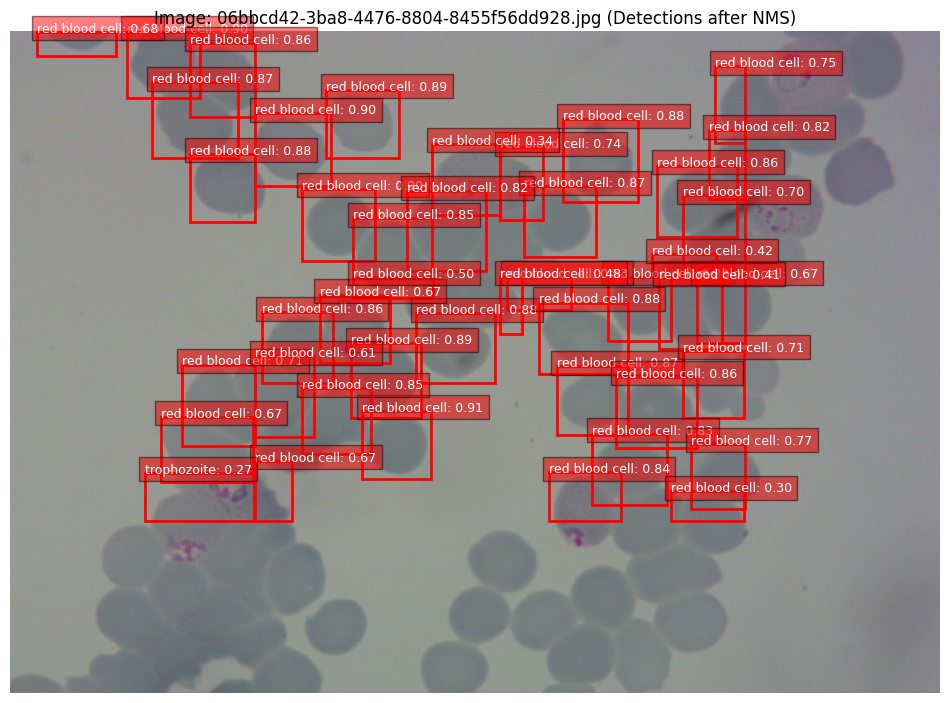


Displayed detections for 06bbcd42-3ba8-4476-8804-8455f56dd928.jpg:
  Class: red blood cell, Confidence: 0.9075, Bbox (xywh): [807.95, 864.32, 144.90, 143.03]
  Class: red blood cell, Confidence: 0.9027, Bbox (xywh): [591.60, 246.70, 157.89, 151.41]
  Class: red blood cell, Confidence: 0.8990, Bbox (xywh): [319.88, 69.10, 153.37, 137.45]
  Class: red blood cell, Confidence: 0.8952, Bbox (xywh): [686.91, 404.09, 152.51, 150.99]
  Class: red blood cell, Confidence: 0.8909, Bbox (xywh): [736.18, 193.07, 151.06, 142.26]
  Class: red blood cell, Confidence: 0.8903, Bbox (xywh): [785.53, 729.82, 146.04, 156.98]
  Class: red blood cell, Confidence: 0.8829, Bbox (xywh): [1233.46, 269.72, 156.96, 172.69]
  Class: red blood cell, Confidence: 0.8823, Bbox (xywh): [931.32, 661.51, 165.07, 145.78]
  Class: red blood cell, Confidence: 0.8822, Bbox (xywh): [1314.90, 579.78, 132.43, 134.87]
  Class: red blood cell, Confidence: 0.8812, Bbox (xywh): [444.27, 326.48, 135.06, 142.88]
  Class: red blood ce

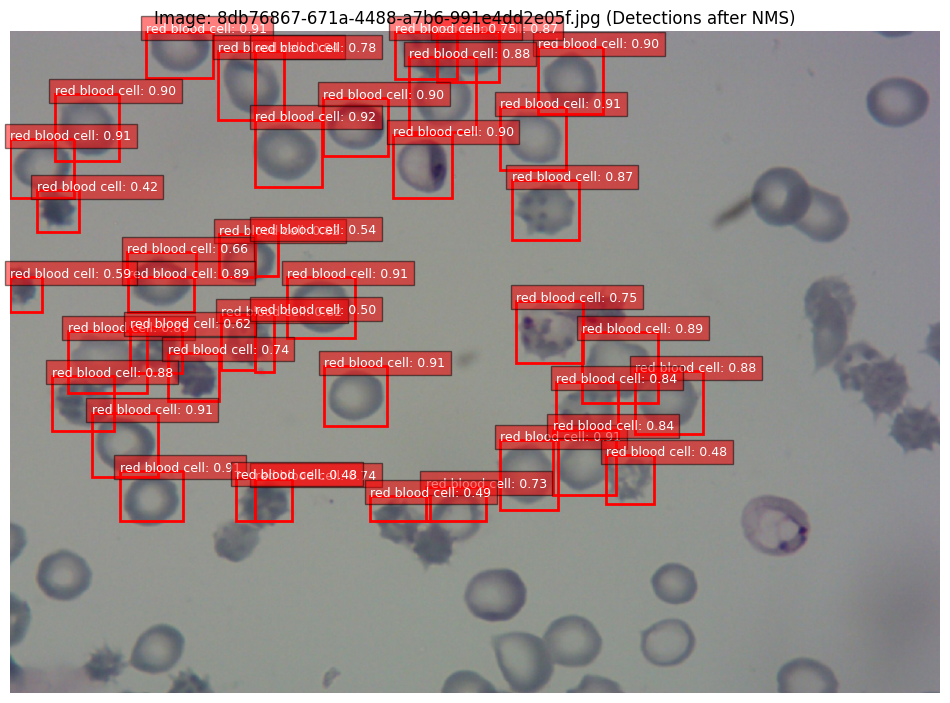


Displayed detections for 8db76867-671a-4488-a7b6-991e4dd2e05f.jpg:
  Class: red blood cell, Confidence: 0.9163, Bbox (xywh): [581.49, 254.39, 138.45, 138.89]
  Class: red blood cell, Confidence: 0.9119, Bbox (xywh): [650.06, 576.77, 141.65, 128.55]
  Class: red blood cell, Confidence: 0.9117, Bbox (xywh): [354.78, 48.56, 140.08, 97.12]
  Class: red blood cell, Confidence: 0.9115, Bbox (xywh): [721.71, 761.91, 130.33, 125.39]
  Class: red blood cell, Confidence: 0.9112, Bbox (xywh): [239.60, 864.41, 137.92, 132.76]
  Class: red blood cell, Confidence: 0.9109, Bbox (xywh): [294.78, 971.16, 130.87, 105.67]
  Class: red blood cell, Confidence: 0.9096, Bbox (xywh): [66.62, 286.66, 132.56, 123.54]
  Class: red blood cell, Confidence: 0.9078, Bbox (xywh): [1093.39, 223.32, 138.02, 130.15]
  Class: red blood cell, Confidence: 0.9052, Bbox (xywh): [1084.91, 926.73, 121.66, 144.59]
  Class: red blood cell, Confidence: 0.9015, Bbox (xywh): [1171.12, 103.16, 134.38, 140.14]
  Class: red blood cel

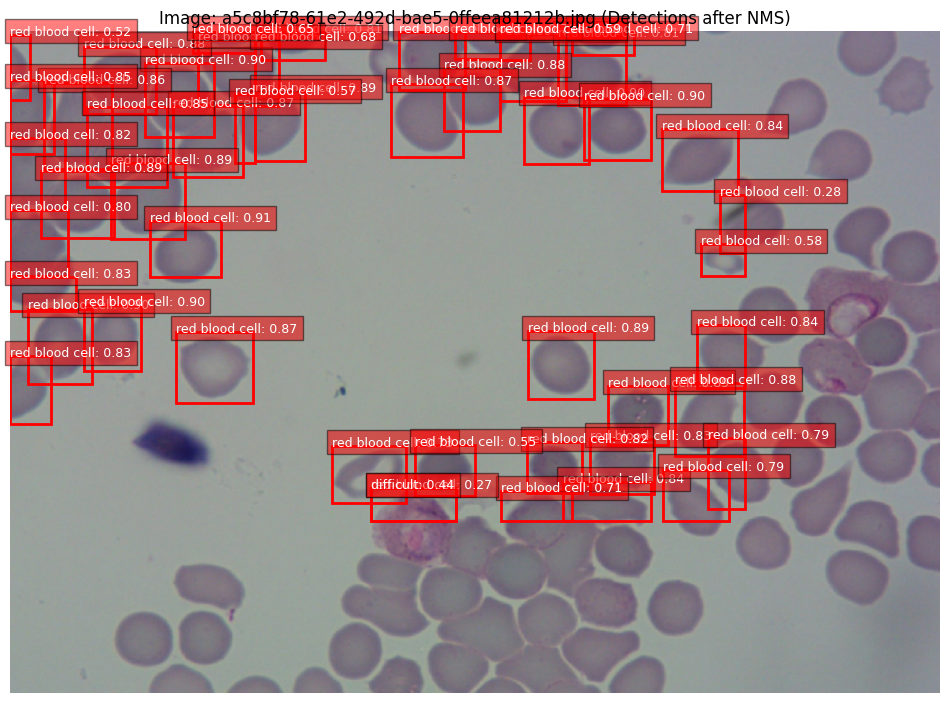


Displayed detections for a5c8bf78-61e2-492d-bae5-0ffeea81212b.jpg:
  Class: red blood cell, Confidence: 0.9139, Bbox (xywh): [1092.62, 74.68, 136.55, 139.50]
  Class: red blood cell, Confidence: 0.9115, Bbox (xywh): [366.61, 454.36, 149.53, 115.22]
  Class: red blood cell, Confidence: 0.9033, Bbox (xywh): [1142.53, 205.87, 136.23, 140.40]
  Class: red blood cell, Confidence: 0.9029, Bbox (xywh): [353.65, 143.05, 143.30, 155.38]
  Class: red blood cell, Confidence: 0.9026, Bbox (xywh): [1269.60, 204.64, 138.77, 128.76]
  Class: red blood cell, Confidence: 0.9003, Bbox (xywh): [103.18, 658.03, 133.89, 158.45]
  Class: red blood cell, Confidence: 0.8956, Bbox (xywh): [214.05, 640.92, 120.40, 139.08]
  Class: red blood cell, Confidence: 0.8931, Bbox (xywh): [288.06, 354.62, 154.72, 158.12]
  Class: red blood cell, Confidence: 0.8926, Bbox (xywh): [1312.05, 801.93, 123.67, 122.55]
  Class: red blood cell, Confidence: 0.8922, Bbox (xywh): [140.70, 361.44, 153.35, 139.78]
  Class: red blood 

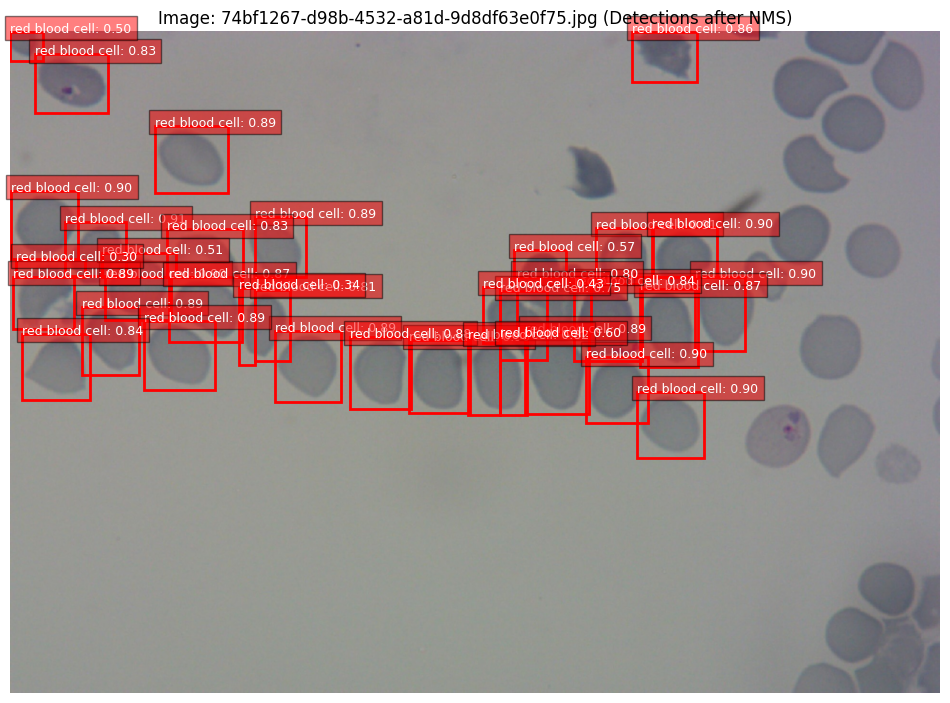


Displayed detections for 74bf1267-d98b-4532-a81d-9d8df63e0f75.jpg:
  Class: red blood cell, Confidence: 0.9089, Bbox (xywh): [1283.88, 461.13, 118.82, 101.71]
  Class: red blood cell, Confidence: 0.9051, Bbox (xywh): [178.71, 454.72, 127.27, 113.71]
  Class: red blood cell, Confidence: 0.9048, Bbox (xywh): [1409.26, 460.30, 134.12, 103.32]
  Class: red blood cell, Confidence: 0.9010, Bbox (xywh): [1380.58, 821.72, 138.90, 137.49]
  Class: red blood cell, Confidence: 0.9006, Bbox (xywh): [71.94, 404.29, 140.00, 143.33]
  Class: red blood cell, Confidence: 0.8976, Bbox (xywh): [1269.07, 749.73, 129.05, 137.50]
  Class: red blood cell, Confidence: 0.8974, Bbox (xywh): [896.92, 721.77, 128.82, 152.91]
  Class: red blood cell, Confidence: 0.8968, Bbox (xywh): [267.23, 556.92, 138.49, 89.84]
  Class: red blood cell, Confidence: 0.8951, Bbox (xywh): [1483.77, 590.36, 104.47, 155.03]
  Class: red blood cell, Confidence: 0.8924, Bbox (xywh): [565.57, 449.35, 107.15, 125.16]
  Class: red blood 

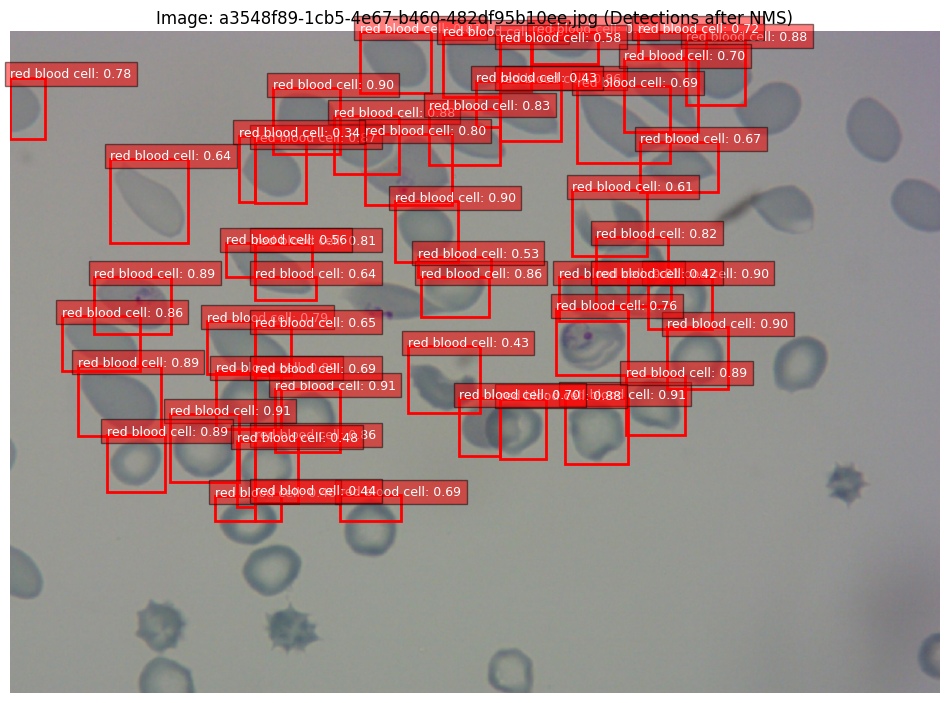


Displayed detections for a3548f89-1cb5-4e67-b460-482df95b10ee.jpg:
  Class: red blood cell, Confidence: 0.9094, Bbox (xywh): [620.51, 812.62, 135.91, 132.66]
  Class: red blood cell, Confidence: 0.9067, Bbox (xywh): [405.88, 871.04, 145.20, 142.53]
  Class: red blood cell, Confidence: 0.9056, Bbox (xywh): [1225.48, 835.13, 132.45, 138.97]
  Class: red blood cell, Confidence: 0.9025, Bbox (xywh): [1437.34, 682.92, 127.78, 129.88]
  Class: red blood cell, Confidence: 0.9014, Bbox (xywh): [1399.92, 567.13, 134.25, 110.25]
  Class: red blood cell, Confidence: 0.9013, Bbox (xywh): [869.83, 418.08, 131.83, 126.01]
  Class: red blood cell, Confidence: 0.8995, Bbox (xywh): [618.62, 187.55, 139.87, 137.63]
  Class: red blood cell, Confidence: 0.8924, Bbox (xywh): [262.55, 902.21, 122.38, 119.09]
  Class: red blood cell, Confidence: 0.8922, Bbox (xywh): [1348.34, 781.76, 122.58, 123.21]
  Class: red blood cell, Confidence: 0.8921, Bbox (xywh): [255.76, 571.90, 160.72, 119.81]
  Class: red blood

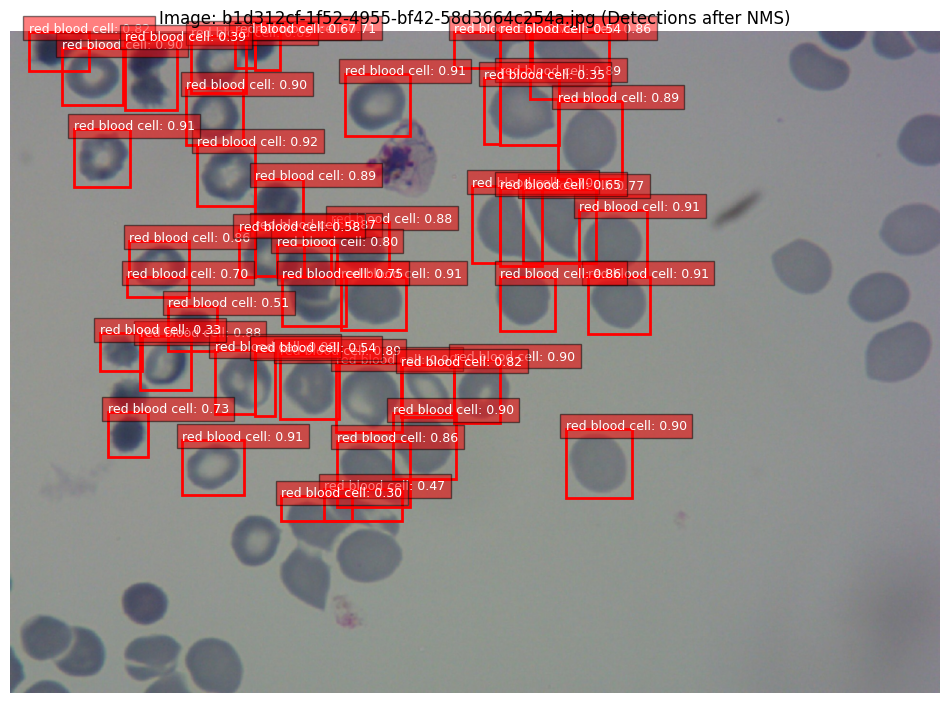


Displayed detections for b1d312cf-1f52-4955-bf42-58d3664c254a.jpg:
  Class: red blood cell, Confidence: 0.9195, Bbox (xywh): [451.31, 300.78, 121.38, 129.15]
  Class: red blood cell, Confidence: 0.9117, Bbox (xywh): [758.51, 567.45, 135.67, 110.91]
  Class: red blood cell, Confidence: 0.9076, Bbox (xywh): [1260.77, 442.06, 142.14, 139.27]
  Class: red blood cell, Confidence: 0.9062, Bbox (xywh): [767.05, 154.29, 136.36, 129.54]
  Class: red blood cell, Confidence: 0.9062, Bbox (xywh): [424.82, 911.36, 129.56, 115.48]
  Class: red blood cell, Confidence: 0.9055, Bbox (xywh): [192.12, 264.40, 118.36, 120.22]
  Class: red blood cell, Confidence: 0.9051, Bbox (xywh): [1272.92, 572.01, 130.84, 119.99]
  Class: red blood cell, Confidence: 0.9037, Bbox (xywh): [427.26, 176.86, 118.35, 118.79]
  Class: red blood cell, Confidence: 0.9033, Bbox (xywh): [865.53, 866.17, 131.66, 137.67]
  Class: red blood cell, Confidence: 0.9031, Bbox (xywh): [1230.55, 903.36, 139.35, 144.94]
  Class: red blood 

In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import random

# Assuming stitched_detections_nms_per_class is available from cell -ITBBgZgZHpN
# Assuming original_img_dir is available from cell -PiDvSLYVTJg
# Assuming model is available from previous cells (for class names)

if 'stitched_detections_nms_per_class' not in locals() or not stitched_detections_nms_per_class:
    print("Error: stitched_detections_nms_per_class not found or is empty. Please run the previous cells first.")
elif 'original_img_dir' not in locals():
     print("Error: original_img_dir not found. Please run cell -PiDvSLYVTJg first.")
elif 'model' not in locals():
     print("Error: model object not found. Please load the model first.")
else:
    # Get a list of original image names that have detections after NMS
    original_images_with_detections = list(stitched_detections_nms_per_class.keys())

    if not original_images_with_detections:
        print("No original images have detections after NMS.")
    else:
        # Select 6 random original image names with detections, or fewer if less than 6 are available
        num_images_to_show = min(6, len(original_images_with_detections))
        selected_images = random.sample(original_images_with_detections, num_images_to_show)


        for original_img_name in selected_images:
            original_img_path = os.path.join(original_img_dir, original_img_name)
            detections = stitched_detections_nms_per_class[original_img_name]

            # Read the original image
            img = cv2.imread(original_img_path)
            if img is None:
                print(f"Error: Could not read image {original_img_path}")
                continue # Skip to the next image if reading fails

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib
            h, w, _ = img.shape

            # Create a figure and axes for each image
            fig, ax = plt.subplots(1, figsize=(12, 9)) # Adjust figure size as needed
            ax.imshow(img)

            # Add bounding boxes and labels
            for det in detections:
                cls_id = int(det[0])
                conf = det[1]
                # Bbox in xywh format (pixel coordinates of original image)
                xc_pixel, yc_pixel, w_pixel, h_pixel = det[2:]

                # Convert xywh (center) to xy (top-left) for matplotlib Rectangle
                x = xc_pixel - w_pixel / 2
                y = yc_pixel - h_pixel / 2

                # Create a Rectangle patch
                # Use different colors for different classes if desired
                color = 'r' # Default color
                if model is not None and hasattr(model, 'names'):
                     # You could map colors to class_id here if you have a color list
                     pass # Example: color = class_colors.get(cls_id, 'r')


                rect = patches.Rectangle((x, y), w_pixel, h_pixel,
                                         linewidth=2, edgecolor=color, facecolor='none')

                # Add the patch to the Axes
                ax.add_patch(rect)

                # Add class label and confidence
                label = f"{model.names.get(cls_id, 'Unknown')}: {conf:.2f}" if model is not None else f"ID {cls_id}: {conf:.2f}"
                plt.text(x, y, label, color='white', fontsize=9, bbox=dict(facecolor=color, alpha=0.5))


            plt.title(f"Image: {original_img_name} (Detections after NMS)")
            plt.axis('off') # Hide axes
            plt.show()

            print(f"\nDisplayed detections for {original_img_name}:")
            for det in detections:
                 cls_id = int(det[0])
                 conf = det[1]
                 bbox = det[2:]
                 class_name = model.names.get(cls_id, "Unknown") if model is not None else f"ID {cls_id}"
                 print(f"  Class: {class_name}, Confidence: {conf:.4f}, Bbox (xywh): [{bbox[0]:.2f}, {bbox[1]:.2f}, {bbox[2]:.2f}, {bbox[3]:.2f}]")

### **1.5.4 Save Final Stitched and NMS-filtered Predictions to Label Files**

In [ ]:
import os
from pathlib import Path

# Assuming stitched_detections_nms_per_class is available from cell -ITBBgZgZHpN
# Assuming original_img_dir is available from cell -PiDvSLYVTJg
# Assuming ORIGINAL_W and ORIGINAL_H are available from cell -PiDvSLYVTJg

output_label_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_stitched_predictions/test/labels_after_nms"

# Create output directory if it doesn't exist
os.makedirs(output_label_dir, exist_ok=True)

print(f"✅ Saving final stitched and NMS-filtered labels to {output_label_dir}...")

if 'stitched_detections_nms_per_class' not in locals() or not stitched_detections_nms_per_class:
    print("Error: stitched_detections_nms_per_class not found or is empty. Please run the previous cells first.")
elif 'ORIGINAL_W' not in locals() or 'ORIGINAL_H' not in locals():
     print("Error: ORIGINAL_W or ORIGINAL_H not found. Please run cell -PiDvSLYVTJg first.")
else:
    for original_img_name, detections in stitched_detections_nms_per_class.items():
        # Assuming original image names stored in stitched_detections_nms_per_class
        # match the stem of the original image files and have a known extension.
        # We'll assume the original image names in the dictionary already have the correct extension.

        output_lbl_path = os.path.join(output_label_dir, Path(original_img_name).stem + ".txt")

        with open(output_lbl_path, "w") as f:
            for det in detections:
                cls_id = int(det[0])
                # conf = det[1] # Confidence is not typically saved in YOLO format labels
                # Bbox in xywh format (pixel coordinates of original image)
                xc_pixel, yc_pixel, w_pixel, h_pixel = det[2:]

                # Convert pixel coordinates back to normalized YOLO format
                xc_norm_orig = xc_pixel / ORIGINAL_W
                yc_norm_orig = yc_pixel / ORIGINAL_H
                w_norm_orig = w_pixel / ORIGINAL_W
                h_norm_orig = h_pixel / ORIGINAL_H

                # Write to file: class_id center_x center_y width height (normalized)
                # Format: class_id x_center y_center width height (all normalized 0-1)
                f.write(f"{cls_id} {xc_norm_orig:.6f} {yc_norm_orig:.6f} {w_norm_orig:.6f} {h_norm_orig:.6f}\n")

    print("\n✅ Final stitched and NMS-filtered labels saved.")

✅ Saving final stitched and NMS-filtered labels to /content/drive/MyDrive/malaria_dataset_4/malaria_stitched_predictions/test/labels_after_nms...

✅ Final stitched and NMS-filtered labels saved.


### **1.5.5 Compare performance on predicted test images versus ground truth on test images**

In [ ]:
# --- Paths ---
original_test_lbl_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria/malaria/labels/test" # Path to original ground truth labels
predicted_test_lbl_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_stitched_predictions/test/labels_after_nms" # Path to saved predicted labels

# Define original image dimensions (needed for normalizing ground truth labels if they are not already)
# Assuming your original ground truth labels are normalized (0-1) relative to these dimensions
ORIGINAL_W, ORIGINAL_H = 1600, 1200 # Define based on your original images

# --- Helper to read YOLO labels safely ---
def read_labels_normalized(lbl_path):
    """Reads YOLO format labels (class_id x_c y_c w h normalized)"""
    if not os.path.exists(lbl_path):
        return []
    try:
        labels = []
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    try:
                        # Ensure class_id is int and bbox coords are floats
                        class_id = int(float(parts[0]))
                        bbox = list(map(float, parts[1:]))
                        labels.append([class_id] + bbox)
                    except ValueError:
                        print(f"⚠️ Skipping invalid line format in {lbl_path}: {line.strip()}")
                        continue
                else:
                     print(f"⚠️ Skipping line with incorrect number of values in {lbl_path}: {line.strip()}")
                     continue
        return labels
    except Exception as e:
        print(f"⚠️ Error reading label file {lbl_path}: {e}")
        return []

# --- IoU between two boxes (normalized xywh format) ---
def iou_normalized_xywh(box1_norm, box2_norm):
    # Convert normalized xywh to normalized xyxy
    x1_min_norm = box1_norm[0] - box1_norm[2]/2
    y1_min_norm = box1_norm[1] - box1_norm[3]/2
    x1_max_norm = box1_norm[0] + box1_norm[2]/2
    y1_max_norm = box1_norm[1] + box1_norm[3]/2

    x2_min_norm = box2_norm[0] - box2_norm[2]/2
    y2_min_norm = box2_norm[1] - box2_norm[3]/2
    x2_max_norm = box2_norm[0] + box2_norm[2]/2
    y2_max_norm = box2_norm[1] + box2_norm[3]/2

    # Get intersection coordinates in normalized space
    xi1_norm = max(x1_min_norm, x2_min_norm)
    yi1_norm = max(y1_min_norm, y2_min_norm)
    xi2_norm = min(x1_max_norm, x2_max_norm)
    yi2_norm = min(y1_max_norm, y2_max_norm)

    # Calculate intersection area in normalized space
    inter_w_norm = max(0, xi2_norm - xi1_norm)
    inter_h_norm = max(0, yi2_norm - yi1_norm)
    inter_area_norm = inter_w_norm * inter_h_norm

    # Calculate box areas in normalized space
    box1_area_norm = (x1_max_norm - x1_min_norm) * (y1_max_norm - y1_min_norm)
    box2_area_norm = (x2_max_norm - x2_min_norm) * (y2_max_norm - y2_min_norm)

    # Calculate union area in normalized space
    union_area_norm = box1_area_norm + box2_area_norm - inter_area_norm

    # Calculate IoU
    return inter_area_norm / union_area_norm if union_area_norm > 0 else 0.0

# --- Compute metrics (Precision, Recall, F1) at a given IoU threshold ---
def compute_metrics_at_iou(predicted_labels, ground_truth_labels, iou_threshold):
    """
    Computes TP, FP, FN, Precision, Recall, F1 for a single image at a given IoU threshold.
    Assumes labels are in [class_id, x_c_norm, y_c_norm, w_norm, h_norm] format.
    """
    tp = 0
    fp = 0
    fn = 0
    matched_gt_indices = set() # To ensure each ground truth box is matched at most once

    # Sort predictions by confidence (assuming confidence is not in the label file,
    # we cannot do proper AP/mAP. This calculates P, R, F1 at a fixed threshold.)
    # If confidence was saved in the predicted label file, we would use it here.
    # For this basic comparison, we treat all predicted boxes as having confidence > threshold.

    # Group predicted and ground truth boxes by class
    gt_by_class = {}
    for gt_label in ground_truth_labels:
        cls_id = int(gt_label[0])
        if cls_id not in gt_by_class:
            gt_by_class[cls_id] = []
        gt_by_class[cls_id].append(gt_label[1:]) # Store only bbox

    pred_by_class = {}
    for pred_label in predicted_labels:
        cls_id = int(pred_label[0])
        if cls_id not in pred_by_class:
            pred_by_class[cls_id] = []
        pred_by_class[cls_id].append(pred_label[1:]) # Store only bbox

    all_class_ids = sorted(list(set(gt_by_class.keys()).union(set(pred_by_class.keys()))))

    metrics_by_class = {}

    for cls_id in all_class_ids:
        current_gt = gt_by_class.get(cls_id, [])
        current_pred = pred_by_class.get(cls_id, [])

        class_tp = 0
        class_matched_gt_indices = set()

        if current_pred:
             # Match predictions to ground truth for the current class
             for pred_idx, p_bbox in enumerate(current_pred):
                 best_iou = 0
                 best_gt_idx = -1

                 for gt_idx, gt_bbox in enumerate(current_gt):
                     # Only consider matching if ground truth hasn't been matched yet by a higher confidence prediction (conceptually)
                     # Since we don't have confidence here, we just ensure each GT is matched once overall for this class
                     if (cls_id, gt_idx) not in matched_gt_indices:
                         iou = iou_normalized_xywh(p_bbox, gt_bbox)
                         if iou > best_iou:
                             best_iou = iou
                             best_gt_idx = gt_idx

                 if best_iou >= iou_threshold:
                     # Check if this GT has already been matched by another prediction of the same class in this image
                     if (cls_id, best_gt_idx) not in matched_gt_indices:
                         class_tp += 1
                         matched_gt_indices.add((cls_id, best_gt_idx))


        class_fp = len(current_pred) - class_tp
        class_fn = len(current_gt) - class_tp

        # Calculate Precision, Recall, and F1 safely
        precision = class_tp / (class_tp + class_fp) if (class_tp + class_fp) > 0 else 0.0
        recall = class_tp / (class_tp + class_fn) if (class_tp + class_fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        metrics_by_class[cls_id] = {
            'tp': class_tp,
            'fp': class_fp,
            'fn': class_fn,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }


    return metrics_by_class, all_class_ids


# --- Compute F1 safely (helper function) ---
def compute_f1(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


# --- Perform Evaluation Across All Test Images ---
evaluation_summary = []
class_names_mapping = {0: 'red blood cell', 1: 'trophozoite', 2: 'ring', 3: 'schizont', 4: 'gametocyte', 5: 'leukocyte', 6: 'difficult'} # Define based on your dataset


iou_threshold_for_metrics = 0.5 # Evaluate at IoU 0.5

print(f"✅ Starting evaluation at IoU threshold {iou_threshold_for_metrics}...")

test_image_files = [f for f in os.listdir(original_test_lbl_dir) if f.endswith(".txt")] # Iterate based on ground truth labels


total_tp = Counter()
total_fp = Counter()
total_fn = Counter()

for lbl_file in test_image_files:
    img_stem = Path(lbl_file).stem
    original_gt_lbl_path = os.path.join(original_test_lbl_dir, lbl_file)
    predicted_lbl_path = os.path.join(predicted_test_lbl_dir, lbl_file) # Predicted label file should have same name

    # Read ground truth and predicted labels (assuming they are normalized)
    ground_truth_labels = read_labels_normalized(original_gt_lbl_path)
    predicted_labels = read_labels_normalized(predicted_lbl_path)

    # Compute metrics for the current image
    metrics_by_class_img, all_class_ids_img = compute_metrics_at_iou(predicted_labels, ground_truth_labels, iou_threshold_for_metrics)

    # Aggregate TP, FP, FN across images
    for cls_id in all_class_ids_img:
        total_tp[cls_id] += metrics_by_class_img[cls_id]['tp']
        total_fp[cls_id] += metrics_by_class_img[cls_id]['fp']
        total_fn[cls_id] += metrics_by_class_img[cls_id]['fn']


# --- Calculate Overall and Per-Class Metrics ---

# Overall Metrics
overall_tp = sum(total_tp.values())
overall_fp = sum(total_fp.values())
overall_fn = sum(total_fn.values())

overall_precision, overall_recall, overall_f1 = compute_f1(overall_tp, overall_fp, overall_fn)


print("\n📊 Overall Evaluation Metrics (IoU=0.5):")
print(f"True Positives (TP): {overall_tp}")
print(f"False Positives (FP): {overall_fp}")
print(f"False Negatives (FN): {overall_fn}")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall:    {overall_recall:.4f}")
print(f"F1 Score:  {overall_f1:.4f}")

# Per-Class Metrics
print("\n📊 Per-Class Evaluation Metrics (IoU=0.5):")

per_class_results = []

# Ensure all possible classes are included, even if TP/FP/FN are 0
all_possible_class_ids = sorted(list(class_names_mapping.keys()))

for cls_id in all_possible_class_ids:
    class_name = class_names_mapping.get(cls_id, f"Unknown_{cls_id}")
    tp = total_tp.get(cls_id, 0)
    fp = total_fp.get(cls_id, 0)
    fn = total_fn.get(cls_id, 0)

    precision, recall, f1 = compute_f1(tp, fp, fn)

    per_class_results.append({
        "Class_ID": cls_id,
        "Class_Name": class_name,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        # Note: mAP calculation requires more sophisticated logic (PR curve)
        # mAP50 and mAP50-95 are not directly calculated in this simplified script.
    })

df_per_class_eval = pd.DataFrame(per_class_results)

# Save to CSV
csv_output_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_stitched_predictions/test/evaluation_metrics_iou_05.csv"
try:
    df_per_class_eval.to_csv(csv_output_path, index=False)
    print(f"\n✅ Per-class evaluation metrics (IoU=0.5) saved to: {csv_output_path}")
except Exception as e:
    print(f"\n⚠️ Error saving per-class evaluation metrics CSV: {e}")


# Display the DataFrame
print(df_per_class_eval.to_string(index=False))

print("\n✅ Evaluation against original ground truth complete (IoU=0.5).")

# Note: For accurate mAP@0.5 and mAP@0.5:0.95, you would typically use the
# Ultralytics `model.val()` method with the appropriate data configuration
# pointing to the original ground truth labels and images. This custom script
# provides P, R, F1 at a single IoU threshold by comparing label files.

✅ Starting evaluation at IoU threshold 0.5...

📊 Overall Evaluation Metrics (IoU=0.5):
True Positives (TP): 347
False Positives (FP): 4410
False Negatives (FN): 5575
Precision: 0.0729
Recall:    0.0586
F1 Score:  0.0650

📊 Per-Class Evaluation Metrics (IoU=0.5):

✅ Per-class evaluation metrics (IoU=0.5) saved to: /content/drive/MyDrive/malaria_dataset_4/malaria_stitched_predictions/test/evaluation_metrics_iou_05.csv
 Class_ID     Class_Name  TP   FP   FN  Precision   Recall  F1_Score
        0 red blood cell 346 4278 5268   0.074827 0.061632  0.067591
        1    trophozoite   0   52  111   0.000000 0.000000  0.000000
        2           ring   1   52  168   0.018868 0.005917  0.009009
        3       schizont   0    1   11   0.000000 0.000000  0.000000
        4     gametocyte   0    0   12   0.000000 0.000000  0.000000
        5      leukocyte   0    0    0   0.000000 0.000000  0.000000
        6      difficult   0   27    5   0.000000 0.000000  0.000000

✅ Evaluation against origin

## **1.6 Final Summary and Conclusion**

This notebook demonstrates a complete workflow for training and evaluating a YOLOv8small size model for object detection on a Malaria parasites dataset, incorporating data patching, class rebalancing through augmentation and weighting, and post-processing steps like prediction remapping, stitching, and Non-Maximum Suppression.

**Workflow Summary:**

1.  **Data Preparation:** The original high-resolution images were patched into smaller tiles suitable for object detection model training.
2.  **Initial Training & Evaluation:** An initial YOLOv8s model was trained, and its performance was evaluated, revealing strong performance on dominant classes (Red Blood Cells) but challenges with rare parasite stages (Schizont, Gametocyte, Difficult). Class imbalance was identified as a key factor.
3.  **Class Rebalancing:** Class weights were calculated based on inverse frequency to address the imbalance.
4.  **Targeted Augmentation:** Targeted augmentation was applied to rare classes (Schizont, Gametocyte) in the training set to increase their representation and diversity.
5.  **Fine-tuning with Rebalancing:** The model was fine-tuned on the patched and augmented dataset using the calculated class weights.
6.  **Evaluation on Validation Set:** The performance of the fine-tuned model was evaluated on the validation set, showing some improvements in precision but a decrease in recall for some rare classes, suggesting the model became more conservative. Data diversity was hypothesized as a limiting factor for rare classes.
7.  **Prediction, Remapping, Stitching, and NMS on Test Set:** The fine-tuned model was used to predict on the patched test set images. The predictions were then remapped back to the original image coordinates, stitched together, and Non-Maximum Suppression (NMS) was applied per class to filter duplicate detections.
8.  **Evaluation and Analysis on Test Set:** The model's performance was evaluated on the test set using standard metrics (Precision, Recall, mAP50, mAP50-95& F1). A comparison of predicted vs. ground truth counts highlighted discrepancies, particularly under-detection of some parasite stages and over-counting of the 'difficult' class.
9.  **Visualization:** An example original image with the final stitched and NMS-filtered predictions was visualized to provide a qualitative assessment.
10. **Saving Final Predictions:** The final processed predictions (stitched and NMS-filtered) were saved to YOLO format label files for all test images.

**Key Findings:**

*   The model achieved good overall performance on the dominant Red Blood Cell class.
*   Despite efforts in rebalancing and augmentation, accurately detecting rare parasite stages (Schizont, Gametocyte) remains challenging, likely due to limited data diversity and sample size even after augmentation.
*   The model tends to be conservative in detecting rare classes, leading to under-counting compared to ground truth for some stages like Trophozoite and Ring.
*   The 'Difficult' class, by its nature, contributes to false positives, as ambiguous objects are often flagged.
*   The patching, remapping, stitching, and NMS pipeline is effective for processing high-resolution images with models trained on smaller patches.

**Next Steps and Potential Improvements:**

*   **More Diverse Data:** The most impactful improvement for rare class detection would likely come from acquiring and labeling more diverse examples of Schizont, Gametocyte, and potentially Ring stages.
*   **Advanced Augmentation:** Explore more sophisticated augmentation techniques specifically designed for medical images or rare classes.
*   **Hyperparameter Tuning:** Further tune the fine-tuning hyperparameters (learning rate, epochs, optimizer settings) to potentially extract more performance.
*   **Ensemble Methods:** Consider combining predictions from multiple models or different training runs.
*   **Thresholding Analysis:** Conduct a detailed analysis of the impact of the confidence threshold on the trade-off between precision and recall for different classes.
*   **Error Analysis:** Continue to visually inspect false positives and false negatives to understand specific failure modes.

This notebook provides a solid foundation for developing a malaria detection model. Addressing the data limitations for rare classes is the most crucial next step for improving its performance on all parasite stages.

**----- THIS MODEL WAS NOT SELECTED FOR PREDICTION ----**